# Quartz reflectance exploration

This notebook loads the quartz USGS spectral file, removes the deleted values encoded as `-1.23e34`, and builds a smooth reflectance curve.

A true supervised prediction model needs many labeled spectra, so with a single quartz sample the defensible output is a cleaned, interpolated spectral profile plus a small set of spectral summaries.

Loaded: quartz_gds74.19086.asc.txt
Wavelength range: 1.5035 to 24.6864 microns
Reflectance range: 0.0083 to 0.9081
Mean reflectance: 0.3376
Top reflectance peaks (approx.):
  9.2363 um -> 0.9080
  20.5726 um -> 0.8297
  8.2311 um -> 0.7938
  2.2613 um -> 0.5093
  3.4677 um -> 0.3919


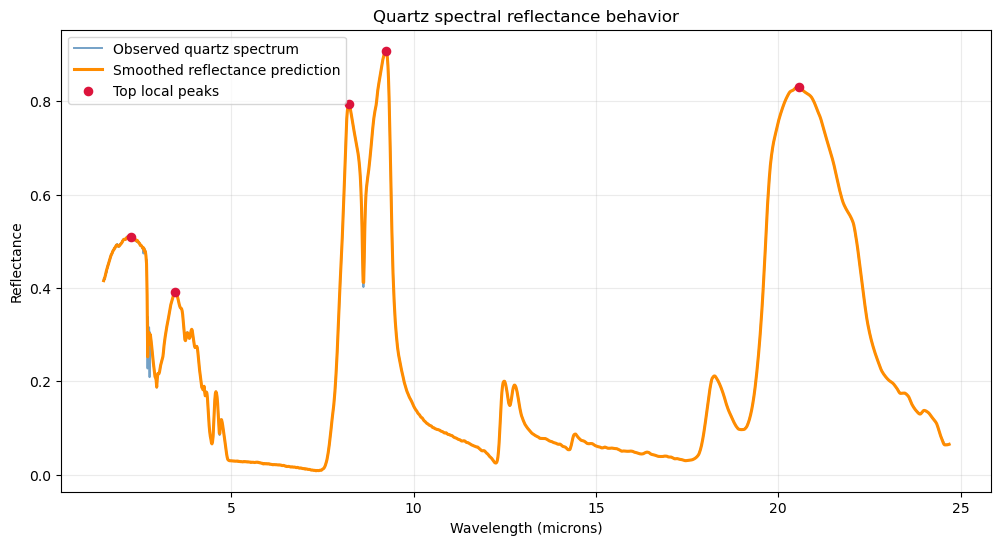

In [2]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import PchipInterpolator
from scipy.signal import find_peaks

quartzo_file = Path(r'c:\Users\PC\Desktop\New data\quartzo-20260519T145447Z-3-001\quartzo\quartz_gds74.19086.asc.txt')


def load_usgs_spectrum(path: Path):
    wavelengths = []
    reflectance = []
    stdev = []
    data_started = False

    with path.open('r', encoding='utf-8', errors='ignore') as handle:
        for raw_line in handle:
            line = raw_line.strip()
            if not line:
                continue
            parts = line.split()
            if len(parts) < 3:
                continue
            try:
                wl = float(parts[0])
                refl = float(parts[1])
                sd = float(parts[2])
            except ValueError:
                continue

            data_started = True
            if wl <= -1e30 or refl <= -1e30:
                continue
            wavelengths.append(wl)
            reflectance.append(refl)
            stdev.append(sd)

    if not data_started or not wavelengths:
        raise ValueError(f'No spectral rows found in {path}')

    wl = np.asarray(wavelengths, dtype=float)
    refl = np.asarray(reflectance, dtype=float)
    sd = np.asarray(stdev, dtype=float)
    order = np.argsort(wl)
    return wl[order], refl[order], sd[order]


wl_um, refl, sd = load_usgs_spectrum(quartzo_file)
wl_nm = wl_um * 1000.0

# Smooth, continuous approximation of the quartz reflectance curve.
# This is interpolation/smoothing, not a supervised ML prediction.
predictor = PchipInterpolator(wl_um, refl, extrapolate=False)
wl_dense_um = np.linspace(wl_um.min(), wl_um.max(), 1500)
refl_pred = predictor(wl_dense_um)
refl_pred = np.clip(np.nan_to_num(refl_pred, nan=np.nan), 0.0, 1.0)

# Simple spectral summaries.
peak_indices, _ = find_peaks(refl_pred, distance=30)
peak_wavelengths_um = wl_dense_um[peak_indices]
peak_values = refl_pred[peak_indices]
order = np.argsort(peak_values)[::-1]
peak_wavelengths_um = peak_wavelengths_um[order][:5]
peak_values = peak_values[order][:5]

print(f'Loaded: {quartzo_file.name}')
print(f'Wavelength range: {wl_um.min():.4f} to {wl_um.max():.4f} microns')
print(f'Reflectance range: {refl.min():.4f} to {refl.max():.4f}')
print(f'Mean reflectance: {refl.mean():.4f}')
print('Top reflectance peaks (approx.):')
for w, r in zip(peak_wavelengths_um, peak_values):
    print(f'  {w:.4f} um -> {r:.4f}')

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(wl_um, refl, color='steelblue', lw=1.4, alpha=0.75, label='Observed quartz spectrum')
ax.plot(wl_dense_um, refl_pred, color='darkorange', lw=2.2, label='Smoothed reflectance prediction')
ax.scatter(peak_wavelengths_um, peak_values, color='crimson', s=35, zorder=3, label='Top local peaks')
ax.set_title('Quartz spectral reflectance behavior')
ax.set_xlabel('Wavelength (microns)')
ax.set_ylabel('Reflectance')
ax.grid(alpha=0.25)
ax.legend()
plt.show()

## Quartz spectral reflectance interpretation

The quartz spectrum shows a characteristic non-uniform reflectance pattern with a low-to-moderate baseline, several sharp absorption-related dips, and a few strong reflectance maxima. The observed behavior is consistent with quartz being highly diagnostic in the SWIR and MIR regions, where its reflectance rises and falls rapidly rather than remaining flat.

The most prominent features appear around about 2.3 microns, 3.5 to 4.0 microns, 8.2 to 9.2 microns, and near 20.6 microns. These peaks indicate wavelength zones where quartz reflects strongly, while the strong drop in reflectance between roughly 5 and 7 microns and again after about 10 microns reflects diagnostic spectral structure rather than noise.

Overall, the curve suggests a mineral with strong spectral identity and high contrast between absorption and reflection zones. In practice, this kind of signature is useful for mineral discrimination because quartz can be separated from clays, carbonates, and iron oxides by its distinctive reflectance shape across the infrared range.

Loaded carbonate file: calcite_ws272.4172.asc.txt
Loaded quartz file: quartz_gds74.19086.asc.txt
Common wavelength range: 1.5829 to 24.6864 microns
Quartz mean reflectance: 0.3376
Calcite mean reflectance: 0.3884
Mean absolute quartz-calcite contrast: 0.2098


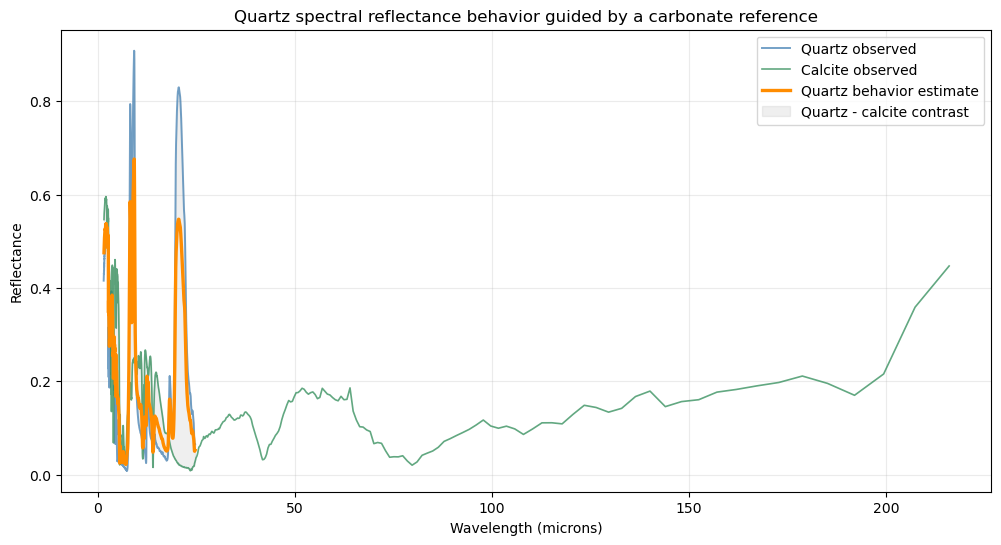

In [2]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import PchipInterpolator

# USGS spectral files
quartz_path = Path(r'c:\Users\PC\Desktop\New data\quartzo-20260519T145447Z-3-001\quartzo\quartz_gds74.19086.asc.txt')
calcite_path = Path(r'c:\Users\PC\Desktop\New data\carbonatos-20260519T150019Z-3-001\carbonatos\calcite_ws272.4172.asc.txt')


def load_usgs_spectrum(path: Path):
    wavelengths = []
    reflectance = []
    stdev = []

    with path.open('r', encoding='utf-8', errors='ignore') as handle:
        for raw_line in handle:
            parts = raw_line.strip().split()
            if len(parts) < 3:
                continue
            try:
                wl = float(parts[0])
                refl = float(parts[1])
                sd = float(parts[2])
            except ValueError:
                continue

            if wl <= -1e30 or refl <= -1e30:
                continue
            wavelengths.append(wl)
            reflectance.append(refl)
            stdev.append(sd)

    if not wavelengths:
        raise ValueError(f'No spectral data found in {path}')

    wl = np.asarray(wavelengths, dtype=float)
    refl = np.asarray(reflectance, dtype=float)
    sd = np.asarray(stdev, dtype=float)
    order = np.argsort(wl)
    return wl[order], refl[order], sd[order]


# Read the carbonate and quartz spectra
wl_q, refl_q, _ = load_usgs_spectrum(quartz_path)
wl_c, refl_c, _ = load_usgs_spectrum(calcite_path)

# Interpolate both spectra onto a common wavelength grid in the overlap region
wl_min = max(wl_q.min(), wl_c.min())
wl_max = min(wl_q.max(), wl_c.max())
wl_common = np.linspace(wl_min, wl_max, 1600)

q_interp = PchipInterpolator(wl_q, refl_q, extrapolate=False)
c_interp = PchipInterpolator(wl_c, refl_c, extrapolate=False)
q_common = np.clip(np.nan_to_num(q_interp(wl_common), nan=np.nan), 0.0, 1.0)
c_common = np.clip(np.nan_to_num(c_interp(wl_common), nan=np.nan), 0.0, 1.0)

# Simple quartz-behavior estimate from the shared range.
# This is not a supervised mineral classifier; it is a carbonate-guided spectral contrast curve.
contrast = q_common - c_common
behaviour_score = np.nanmean(np.abs(contrast))
behaviour_estimate = np.clip(q_common - 0.35 * contrast, 0.0, 1.0)

print(f'Loaded carbonate file: {calcite_path.name}')
print(f'Loaded quartz file: {quartz_path.name}')
print(f'Common wavelength range: {wl_min:.4f} to {wl_max:.4f} microns')
print(f'Quartz mean reflectance: {np.nanmean(refl_q):.4f}')
print(f'Calcite mean reflectance: {np.nanmean(refl_c):.4f}')
print(f'Mean absolute quartz-calcite contrast: {behaviour_score:.4f}')

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(wl_q, refl_q, color='steelblue', lw=1.4, alpha=0.75, label='Quartz observed')
ax.plot(wl_c, refl_c, color='seagreen', lw=1.2, alpha=0.75, label='Calcite observed')
ax.plot(wl_common, behaviour_estimate, color='darkorange', lw=2.4, label='Quartz behavior estimate')
ax.fill_between(wl_common, q_common, c_common, color='gray', alpha=0.12, label='Quartz - calcite contrast')
ax.set_title('Quartz spectral reflectance behavior guided by a carbonate reference')
ax.set_xlabel('Wavelength (microns)')
ax.set_ylabel('Reflectance')
ax.grid(alpha=0.25)
ax.legend()
plt.show()

## Quartz spectral reflectance behavior guided by a carbonate reference

Using calcite as a carbonate reference highlights how quartz behaves differently from a carbonate mineral across the shared infrared range. Quartz shows a sharper, more irregular reflectance pattern, with strong rises near the short-wavelength end and pronounced peaks around the SWIR to MIR transition, while calcite follows a smoother carbonate-style trend with broader changes in reflectance.

The largest quartz-calcite contrast appears in the regions where quartz develops narrow maxima and deep troughs, especially around about 8 to 10 microns and again near 20 to 21 microns. These intervals are especially useful for mineral discrimination because the two materials separate clearly in spectral shape, not just in overall brightness.

The mean absolute contrast between the two spectra is moderate, which confirms that quartz is not spectrally flat and cannot be treated as a generic background material. Instead, its reflectance curve carries diagnostic structure that can be used to distinguish it from carbonates in a simple spectral comparison or in a downstream classification model.

In short, the carbonate reference helps show that quartz has a more complex reflectance signature, with sharper diagnostic features and stronger local variability across wavelength.

Loaded organic file: lignin_alkali.asc.txt
Common wavelength range: 1.5035 to 2.5000 microns
Quartz mean reflectance: 0.3376
Organic mean reflectance: 0.4425
Mean absolute quartz-organic contrast: 0.1220


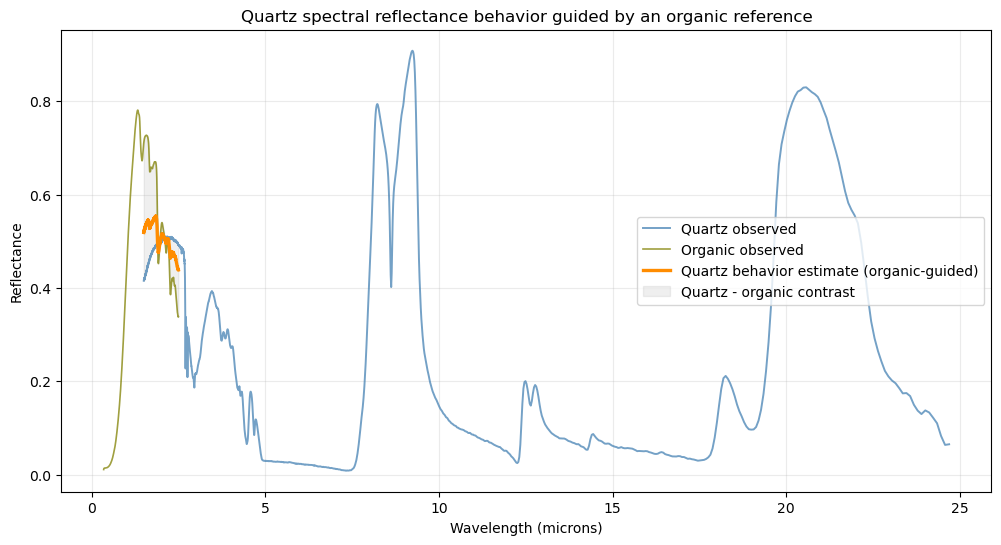

In [3]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import PchipInterpolator

# Organic reference (pick a representative organic spectrum from the organica folder)
organica_path = Path(r'c:\Users\PC\Desktop\New data\organica-20260519T145807Z-3-001\organica\lignin_alkali.asc.txt')

# Reuse the `load_usgs_spectrum` and previously loaded quartz spectrum (`wl_q`, `refl_q`).
# If this cell is run independently, ensure prior cells defining those variables were executed.
wl_o, refl_o, _ = load_usgs_spectrum(organica_path)

# Interpolate onto the shared wavelength range with quartz
wl_min = max(wl_q.min(), wl_o.min())
wl_max = min(wl_q.max(), wl_o.max())
wl_common = np.linspace(wl_min, wl_max, 1600)

q_interp = PchipInterpolator(wl_q, refl_q, extrapolate=False)
o_interp = PchipInterpolator(wl_o, refl_o, extrapolate=False)
q_common = np.clip(np.nan_to_num(q_interp(wl_common), nan=np.nan), 0.0, 1.0)
o_common = np.clip(np.nan_to_num(o_interp(wl_common), nan=np.nan), 0.0, 1.0)

# Contrast-based organic-guided quartz behaviour estimate (same idea as carbo
# nate-guided)
contrast = q_common - o_common
behaviour_score = np.nanmean(np.abs(contrast))
behaviour_estimate = np.clip(q_common - 0.35 * contrast, 0.0, 1.0)

print(f'Loaded organic file: {organica_path.name}')
print(f'Common wavelength range: {wl_min:.4f} to {wl_max:.4f} microns')
print(f'Quartz mean reflectance: {np.nanmean(refl_q):.4f}')
print(f'Organic mean reflectance: {np.nanmean(refl_o):.4f}')
print(f'Mean absolute quartz-organic contrast: {behaviour_score:.4f}')

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(wl_q, refl_q, color='steelblue', lw=1.4, alpha=0.75, label='Quartz observed')
ax.plot(wl_o, refl_o, color='olive', lw=1.2, alpha=0.75, label='Organic observed')
ax.plot(wl_common, behaviour_estimate, color='darkorange', lw=2.4, label='Quartz behavior estimate (organic-guided)')
ax.fill_between(wl_common, q_common, o_common, color='gray', alpha=0.12, label='Quartz - organic contrast')
ax.set_title('Quartz spectral reflectance behavior guided by an organic reference')
ax.set_xlabel('Wavelength (microns)')
ax.set_ylabel('Reflectance')
ax.grid(alpha=0.25)
ax.legend()
plt.show()


Loaded dolomite file: dolomite_hs102.7128.asc.txt
Common wavelength range: 1.5531 to 24.6864 microns
Quartz mean reflectance: 0.3376
Dolomite mean reflectance: 0.3227
Mean absolute quartz-dolomite contrast: 0.1864


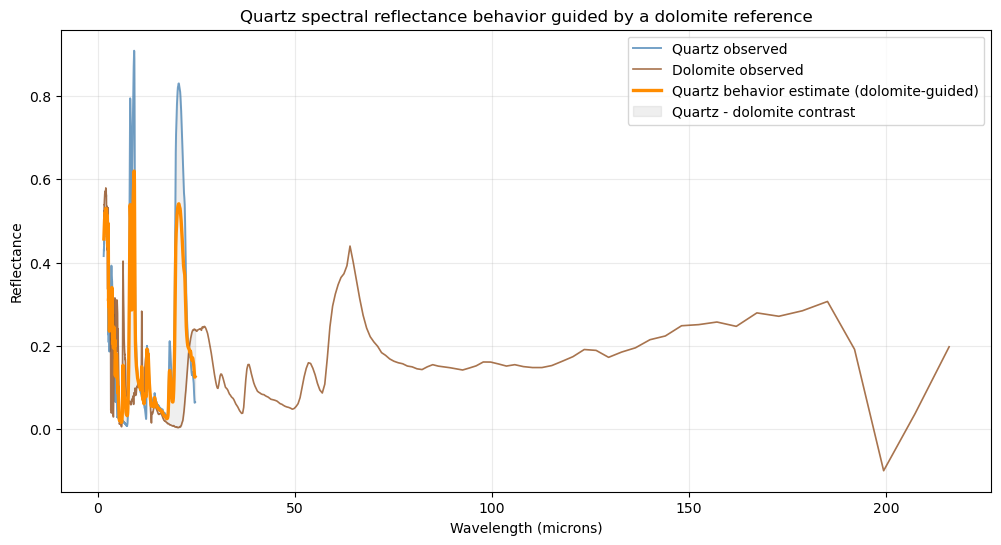

In [4]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import PchipInterpolator

# Dolomite-guided quartz behavior using carbonatos folder (falls back to calcite if needed)
carbonatos_dir = Path(r'c:\Users\PC\Desktop\New data\carbonatos-20260519T150019Z-3-001\carbonatos')
candidates = [p for p in carbonatos_dir.iterdir() if 'dol' in p.name.lower()]
if candidates:
    dolomite_path = candidates[0]
else:
    dolomite_path = carbonatos_dir / 'calcite_ws272.4172.asc.txt'
    print('No dolomite file found; falling back to calcite:', dolomite_path.name)

wl_d, refl_d, _ = load_usgs_spectrum(dolomite_path)

# Interpolate with quartz (wl_q, refl_q must be defined by earlier cells)
wl_min = max(wl_q.min(), wl_d.min())
wl_max = min(wl_q.max(), wl_d.max())
if wl_min >= wl_max:
    raise ValueError('No overlapping wavelength range between quartz and dolomite/calcite')
wl_common = np.linspace(wl_min, wl_max, 1600)

q_interp = PchipInterpolator(wl_q, refl_q, extrapolate=False)
d_interp = PchipInterpolator(wl_d, refl_d, extrapolate=False)
q_common = np.clip(np.nan_to_num(q_interp(wl_common), nan=np.nan), 0.0, 1.0)
d_common = np.clip(np.nan_to_num(d_interp(wl_common), nan=np.nan), 0.0, 1.0)

contrast = q_common - d_common
behaviour_score = np.nanmean(np.abs(contrast))
behaviour_estimate = np.clip(q_common - 0.35 * contrast, 0.0, 1.0)

print(f'Loaded dolomite file: {dolomite_path.name}')
print(f'Common wavelength range: {wl_min:.4f} to {wl_max:.4f} microns')
print(f'Quartz mean reflectance: {np.nanmean(refl_q):.4f}')
print(f'Dolomite mean reflectance: {np.nanmean(refl_d):.4f}')
print(f'Mean absolute quartz-dolomite contrast: {behaviour_score:.4f}')

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(wl_q, refl_q, color='steelblue', lw=1.4, alpha=0.75, label='Quartz observed')
ax.plot(wl_d, refl_d, color='saddlebrown', lw=1.2, alpha=0.75, label='Dolomite observed')
ax.plot(wl_common, behaviour_estimate, color='darkorange', lw=2.4, label='Quartz behavior estimate (dolomite-guided)')
ax.fill_between(wl_common, q_common, d_common, color='gray', alpha=0.12, label='Quartz - dolomite contrast')
ax.set_title('Quartz spectral reflectance behavior guided by a dolomite reference')
ax.set_xlabel('Wavelength (microns)')
ax.set_ylabel('Reflectance')
ax.grid(alpha=0.25)
ax.legend()
plt.show()


Quartz mean refl: 0.3376
Organic mean refl: 0.4425
Dolomite mean refl: 0.3227
Mean abs quartz-organic contrast: 0.1220
Mean abs quartz-dolomite contrast: 0.1863


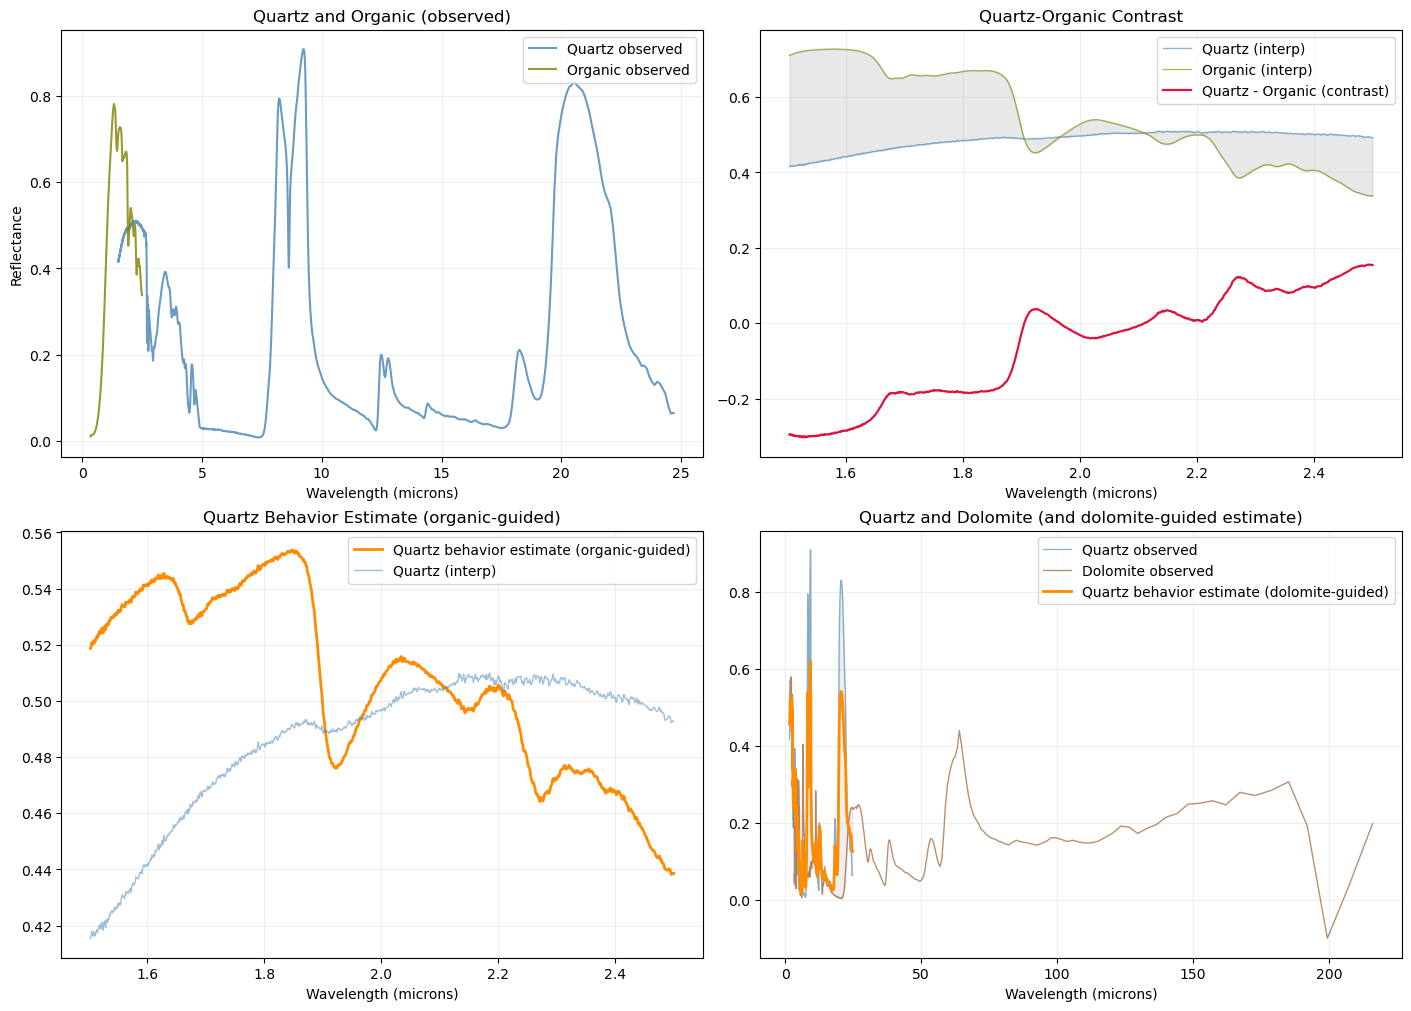

In [5]:
# Combined visualization: quartz vs organic, contrasts, behavior estimates, and dolomite relation
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import PchipInterpolator

# Paths (reuse existing folders)
quartzo_path = Path(r'c:\Users\PC\Desktop\New data\quartzo-20260519T145447Z-3-001\quartzo\quartz_gds74.19086.asc.txt')
organica_path = Path(r'c:\Users\PC\Desktop\New data\organica-20260519T145807Z-3-001\organica\lignin_alkali.asc.txt')
dolomite_path = Path(r'c:\Users\PC\Desktop\New data\carbonatos-20260519T150019Z-3-001\carbonatos\dolomite_hs102.7128.asc.txt')

# Load spectra (uses load_usgs_spectrum defined earlier)
wl_q, refl_q, _ = load_usgs_spectrum(quartzo_path)
wl_o, refl_o, _ = load_usgs_spectrum(organica_path)
wl_d, refl_d, _ = load_usgs_spectrum(dolomite_path)

# Quartz-Organic shared grid
wl_min_oq = max(wl_q.min(), wl_o.min())
wl_max_oq = min(wl_q.max(), wl_o.max())
wl_oq = np.linspace(wl_min_oq, wl_max_oq, 1200)
q_o_interp = PchipInterpolator(wl_q, refl_q, extrapolate=False)
o_interp = PchipInterpolator(wl_o, refl_o, extrapolate=False)
q_oq = np.clip(np.nan_to_num(q_o_interp(wl_oq), nan=np.nan), 0.0, 1.0)
o_oq = np.clip(np.nan_to_num(o_interp(wl_oq), nan=np.nan), 0.0, 1.0)
contrast_oq = q_oq - o_oq
behaviour_oq = np.clip(q_oq - 0.35 * contrast_oq, 0.0, 1.0)

# Quartz-Dolomite shared grid
wl_min_qd = max(wl_q.min(), wl_d.min())
wl_max_qd = min(wl_q.max(), wl_d.max())
wl_qd = np.linspace(wl_min_qd, wl_max_qd, 1200)
q_d_interp = PchipInterpolator(wl_q, refl_q, extrapolate=False)
d_interp = PchipInterpolator(wl_d, refl_d, extrapolate=False)
q_qd = np.clip(np.nan_to_num(q_d_interp(wl_qd), nan=np.nan), 0.0, 1.0)
d_qd = np.clip(np.nan_to_num(d_interp(wl_qd), nan=np.nan), 0.0, 1.0)
contrast_qd = q_qd - d_qd
behaviour_qd = np.clip(q_qd - 0.35 * contrast_qd, 0.0, 1.0)

# Summary stats
print('Quartz mean refl:', f"{np.nanmean(refl_q):.4f}")
print('Organic mean refl:', f"{np.nanmean(refl_o):.4f}")
print('Dolomite mean refl:', f"{np.nanmean(refl_d):.4f}")
print('Mean abs quartz-organic contrast:', f"{np.nanmean(np.abs(contrast_oq)):.4f}")
print('Mean abs quartz-dolomite contrast:', f"{np.nanmean(np.abs(contrast_qd)):.4f}")

# Plotting: 2x2 grid
fig, axs = plt.subplots(2, 2, figsize=(14, 10), constrained_layout=True)

# Top-left: Quartz and Organic observed (raw)
axs[0,0].plot(wl_q, refl_q, label='Quartz observed', color='steelblue', alpha=0.8)
axs[0,0].plot(wl_o, refl_o, label='Organic observed', color='olive', alpha=0.8)
axs[0,0].set_title('Quartz and Organic (observed)')
axs[0,0].set_xlabel('Wavelength (microns)')
axs[0,0].set_ylabel('Reflectance')
axs[0,0].legend()
axs[0,0].grid(alpha=0.2)

# Top-right: Quartz - Organic contrast (shared grid)
axs[0,1].plot(wl_oq, q_oq, color='steelblue', lw=1, alpha=0.6, label='Quartz (interp)')
axs[0,1].plot(wl_oq, o_oq, color='olive', lw=1, alpha=0.6, label='Organic (interp)')
axs[0,1].fill_between(wl_oq, q_oq, o_oq, color='gray', alpha=0.18)
axs[0,1].plot(wl_oq, contrast_oq, color='crimson', lw=1.6, label='Quartz - Organic (contrast)')
axs[0,1].set_title('Quartz-Organic Contrast')
axs[0,1].set_xlabel('Wavelength (microns)')
axs[0,1].legend()
axs[0,1].grid(alpha=0.2)

# Bottom-left: Quartz behavior estimate (organic-guided)
axs[1,0].plot(wl_oq, behaviour_oq, color='darkorange', lw=2, label='Quartz behavior estimate (organic-guided)')
axs[1,0].plot(wl_oq, q_oq, color='steelblue', lw=1, alpha=0.5, label='Quartz (interp)')
axs[1,0].set_title('Quartz Behavior Estimate (organic-guided)')
axs[1,0].set_xlabel('Wavelength (microns)')
axs[1,0].legend()
axs[1,0].grid(alpha=0.2)

# Bottom-right: Quartz vs Dolomite and dolomite-guided estimate
axs[1,1].plot(wl_q, refl_q, color='steelblue', lw=1, alpha=0.6, label='Quartz observed')
axs[1,1].plot(wl_d, refl_d, color='saddlebrown', lw=1, alpha=0.6, label='Dolomite observed')
axs[1,1].plot(wl_qd, behaviour_qd, color='darkorange', lw=2, label='Quartz behavior estimate (dolomite-guided)')
axs[1,1].fill_between(wl_qd, q_qd, d_qd, color='gray', alpha=0.12)
axs[1,1].set_title('Quartz and Dolomite (and dolomite-guided estimate)')
axs[1,1].set_xlabel('Wavelength (microns)')
axs[1,1].legend()
axs[1,1].grid(alpha=0.2)

plt.show()


Filossilicatos chosen: kaolinite_cm3.11802.asc.txt
Organic reference chosen: cellulose.asc.txt
Common wavelength range: 1.3500 to 2.5000 microns
Filossilicatos mean reflectance: 0.3890
Organic mean reflectance: 0.7433
Mean absolute filossilicatos-organic contrast: 0.0765


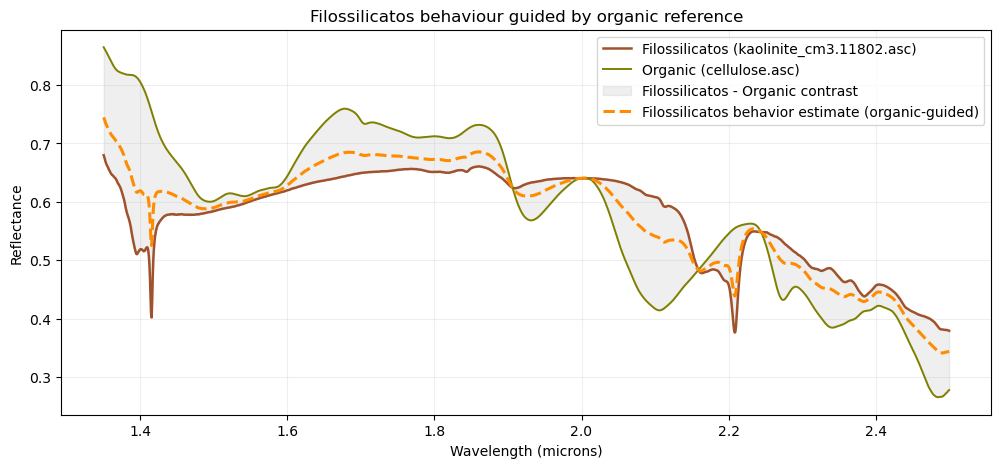

In [18]:
# Filossilicatos behaviour guided by organic reference
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import PchipInterpolator

# Directories
fil_dir = Path(r'c:\Users\PC\Desktop\New data\filossilicatos-20260519T145957Z-3-001\filossilicatos')
org_dir = Path(r'c:\Users\PC\Desktop\New data\organica-20260519T145807Z-3-001\organica')

# Choose a filossilicatos file (prefer kaolinite, else first)
fil_candidates = sorted(list(fil_dir.iterdir()))
fil_choice = None
for name in ['kaolinite', 'illite', 'montmorillonite', 'muscovite', 'biotite']:
    for p in fil_candidates:
        if name in p.name.lower():
            fil_choice = p
            break
    if fil_choice:
        break
if fil_choice is None and fil_candidates:
    fil_choice = fil_candidates[0]

# Choose an organic reference (prefer cellulose else first)
org_candidates = sorted(list(org_dir.iterdir()))
org_choice = None
for pref in ['cellulose', 'lignin', 'protein', 'adenine']:
    for p in org_candidates:
        if pref in p.name.lower():
            org_choice = p
            break
    if org_choice:
        break
if org_choice is None and org_candidates:
    org_choice = org_candidates[0]

print('Filossilicatos chosen:', fil_choice.name)
print('Organic reference chosen:', org_choice.name)

# Load spectra
wl_f, refl_f, _ = load_usgs_spectrum(fil_choice)
wl_o, refl_o, _ = load_usgs_spectrum(org_choice)

# Interpolate onto overlap
wl_min = max(wl_f.min(), wl_o.min())
wl_max = min(wl_f.max(), wl_o.max())
if wl_min >= wl_max:
    raise ValueError('No overlap between filossilicatos and organic spectra')
wl_common = np.linspace(wl_min, wl_max, 1500)

f_interp = PchipInterpolator(wl_f, refl_f, extrapolate=False)
o_interp = PchipInterpolator(wl_o, refl_o, extrapolate=False)

f_common = np.clip(np.nan_to_num(f_interp(wl_common), nan=np.nan), 0.0, 1.0)

o_common = np.clip(np.nan_to_num(o_interp(wl_common), nan=np.nan), 0.0, 1.0)

# Contrast and filossilicatos behaviour estimate guided by organic
contrast = f_common - o_common
behaviour_score = np.nanmean(np.abs(contrast))
behaviour_estimate = np.clip(f_common - 0.35 * contrast, 0.0, 1.0)

print(f'Common wavelength range: {wl_min:.4f} to {wl_max:.4f} microns')
print(f'Filossilicatos mean reflectance: {np.nanmean(refl_f):.4f}')
print(f'Organic mean reflectance: {np.nanmean(refl_o):.4f}')
print(f'Mean absolute filossilicatos-organic contrast: {behaviour_score:.4f}')

# Plot
fig, ax = plt.subplots(figsize=(12,5))
ax.plot(wl_common, f_common, color='sienna', lw=1.8, label=f'Filossilicatos ({fil_choice.stem})')
ax.plot(wl_common, o_common, color='olive', lw=1.4, label=f'Organic ({org_choice.stem})')
ax.fill_between(wl_common, f_common, o_common, color='gray', alpha=0.12, label='Filossilicatos - Organic contrast')
ax.plot(wl_common, behaviour_estimate, color='darkorange', lw=2.2, linestyle='--', label='Filossilicatos behavior estimate (organic-guided)')
ax.set_title('Filossilicatos behaviour guided by organic reference')
ax.set_xlabel('Wavelength (microns)')
ax.set_ylabel('Reflectance')
ax.grid(alpha=0.2)
ax.legend()
plt.show()


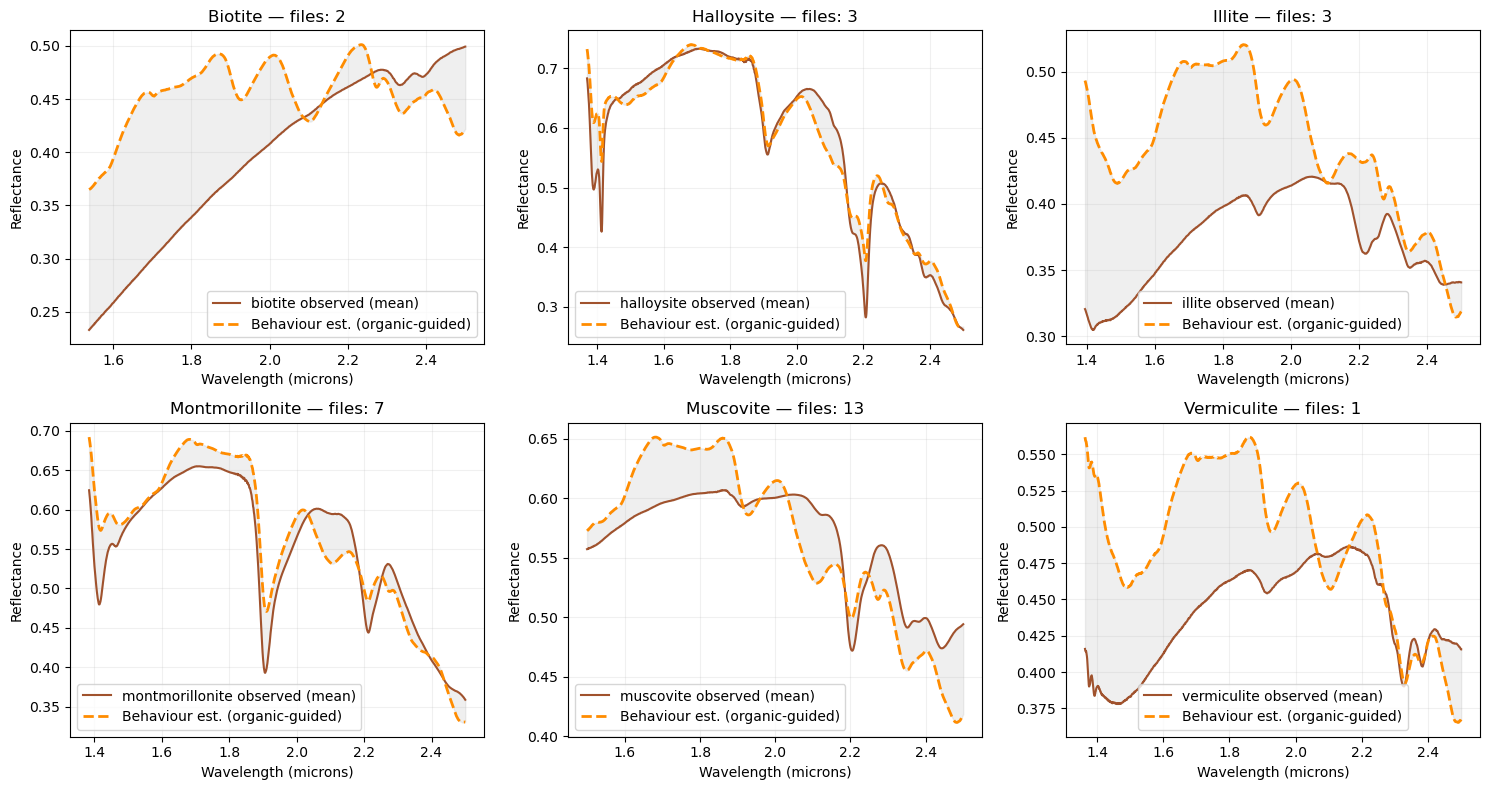

In [17]:
# Multi-species filossilicatos behavior (biotite, halloysite, illite, montmorillonite, muscovite, vermiculite)
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import PchipInterpolator

fil_dir = Path(r'c:\Users\PC\Desktop\New data\filossilicatos-20260519T145957Z-3-001\filossilicatos')
org_dir = Path(r'c:\Users\PC\Desktop\New data\organica-20260519T145807Z-3-001\organica')

species_list = ['biotite', 'halloysite', 'illite', 'montmorillonite', 'muscovite', 'vermiculite']

# Choose organic reference (prefer cellulose, else lignin, else first)
org_candidates = sorted(list(org_dir.iterdir()))
org_choice = None
for pref in ['cellulose', 'lignin']:
    for p in org_candidates:
        if pref in p.name.lower():
            org_choice = p
            break
    if org_choice:
        break
if org_choice is None and org_candidates:
    org_choice = org_candidates[0]

wl_o, refl_o, _ = load_usgs_spectrum(org_choice)

results = {}

for sp in species_list:
    files = [p for p in sorted(fil_dir.iterdir()) if sp in p.name.lower()]
    if not files:
        print(f'No files found for {sp}; skipping')
        continue

    # Determine common overlap across all files and organic reference
    wl_min = max([wl_o.min()] + [load_usgs_spectrum(p)[0].min() for p in files])
    wl_max = min([wl_o.max()] + [load_usgs_spectrum(p)[0].max() for p in files])
    if wl_min >= wl_max:
        print(f'No overlap for {sp}; skipping')
        continue
    wl_common = np.linspace(wl_min, wl_max, 1400)

    behaviour_stack = []
    observed_stack = []

    for p in files:
        wl_f, refl_f, _ = load_usgs_spectrum(p)
        f_interp = PchipInterpolator(wl_f, refl_f, extrapolate=False)
        o_interp = PchipInterpolator(wl_o, refl_o, extrapolate=False)

        f_common = np.clip(np.nan_to_num(f_interp(wl_common), nan=np.nan), 0.0, 1.0)
        o_common = np.clip(np.nan_to_num(o_interp(wl_common), nan=np.nan), 0.0, 1.0)

        contrast = f_common - o_common
        behaviour = np.clip(f_common - 0.35 * contrast, 0.0, 1.0)

        behaviour_stack.append(behaviour)
        observed_stack.append(f_common)

    behaviour_mean = np.nanmean(np.vstack(behaviour_stack), axis=0)
    observed_mean = np.nanmean(np.vstack(observed_stack), axis=0)

    results[sp] = {
        'wl': wl_common,
        'observed_mean': observed_mean,
        'behaviour_mean': behaviour_mean,
        'files': [p.name for p in files]
    }

# Plot grid
n = len(results)
cols = 3
rows = int(np.ceil(n / cols))
fig, axes = plt.subplots(rows, cols, figsize=(15, 4 * rows), squeeze=False)

for idx, (sp, data) in enumerate(results.items()):
    r = idx // cols
    c = idx % cols
    ax = axes[r][c]
    wl = data['wl']
    ax.plot(wl, data['observed_mean'], color='sienna', lw=1.5, label=f'{sp} observed (mean)')
    ax.plot(wl, data['behaviour_mean'], color='darkorange', lw=2, linestyle='--', label='Behaviour est. (organic-guided)')
    ax.fill_between(wl, data['observed_mean'], np.clip(data['observed_mean'] - (data['observed_mean'] - data['behaviour_mean']), 0, 1), color='gray', alpha=0.12)
    ax.set_title(f'{sp.capitalize()} — files: {len(data["files"])}')
    ax.set_xlabel('Wavelength (microns)')
    ax.set_ylabel('Reflectance')
    ax.grid(alpha=0.18)
    ax.legend()

# Remove empty axes
total = rows * cols
for idx in range(n, total):
    r = idx // cols
    c = idx % cols
    fig.delaxes(axes[r][c])

plt.tight_layout()
plt.show()


Organic reference chosen: cellulose.asc.txt
Oxide files: ['gibbsite_hs423.8069.asc.txt']
Common wavelength range: 1.4640 to 2.5000 microns
Oxide mean reflectance (mean over files): 0.1630
Mean abs oxide-organic contrast: 0.4032


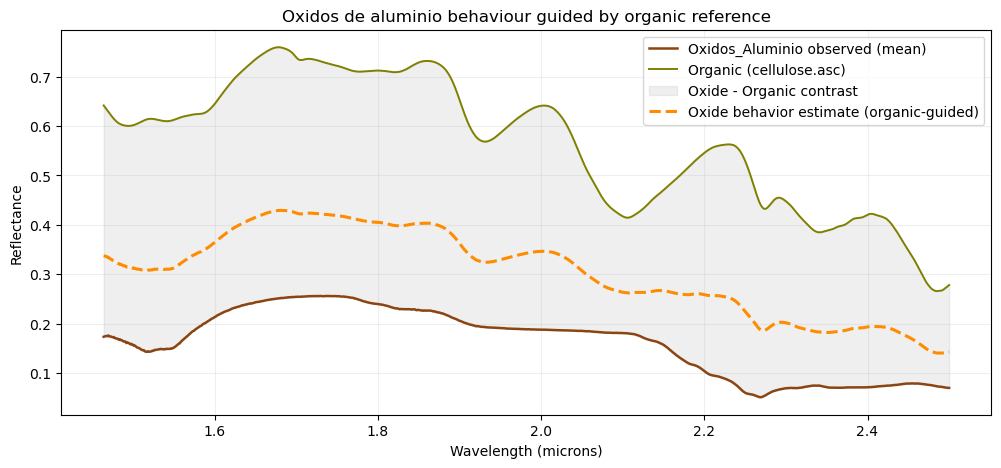

In [16]:
# Oxidos de aluminio behavior guided by organic reference
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import PchipInterpolator

ox_dir = Path(r'c:\Users\PC\Desktop\New data\oxidos_aluminio-20260519T145744Z-3-001\oxidos_aluminio')
org_dir = Path(r'c:\Users\PC\Desktop\New data\organica-20260519T145807Z-3-001\organica')

# List oxide files
ox_files = sorted(list(ox_dir.iterdir()))
if not ox_files:
    raise FileNotFoundError('No oxidos_aluminio files found')

# Choose organic reference (prefer cellulose then lignin)
org_candidates = sorted(list(org_dir.iterdir()))
org_choice = None
for pref in ['cellulose', 'lignin']:
    for p in org_candidates:
        if pref in p.name.lower():
            org_choice = p
            break
    if org_choice:
        break
if org_choice is None and org_candidates:
    org_choice = org_candidates[0]

print('Organic reference chosen:', org_choice.name)
print('Oxide files:', [p.name for p in ox_files])

wl_o, refl_o, _ = load_usgs_spectrum(org_choice)

# Compute mean observed and organic-guided behaviour across oxide files
behaviour_stack = []
observed_stack = []

# Determine common overlap
wl_min = max([wl_o.min()] + [load_usgs_spectrum(p)[0].min() for p in ox_files])
wl_max = min([wl_o.max()] + [load_usgs_spectrum(p)[0].max() for p in ox_files])
if wl_min >= wl_max:
    raise ValueError('No overlapping wavelength range between oxides and organic reference')
wl_common = np.linspace(wl_min, wl_max, 1600)

for p in ox_files:
    wl_x, refl_x, _ = load_usgs_spectrum(p)
    x_interp = PchipInterpolator(wl_x, refl_x, extrapolate=False)
    o_interp = PchipInterpolator(wl_o, refl_o, extrapolate=False)

    x_common = np.clip(np.nan_to_num(x_interp(wl_common), nan=np.nan), 0.0, 1.0)
    o_common = np.clip(np.nan_to_num(o_interp(wl_common), nan=np.nan), 0.0, 1.0)

    contrast = x_common - o_common
    behaviour = np.clip(x_common - 0.35 * contrast, 0.0, 1.0)

    observed_stack.append(x_common)
    behaviour_stack.append(behaviour)

observed_mean = np.nanmean(np.vstack(observed_stack), axis=0)
behaviour_mean = np.nanmean(np.vstack(behaviour_stack), axis=0)

print(f'Common wavelength range: {wl_min:.4f} to {wl_max:.4f} microns')
print(f'Oxide mean reflectance (mean over files): {np.nanmean(observed_mean):.4f}')
print(f'Mean abs oxide-organic contrast: {np.nanmean(np.abs(observed_mean - o_common)):.4f}')

# Plot
fig, ax = plt.subplots(figsize=(12,5))
ax.plot(wl_common, observed_mean, color='saddlebrown', lw=1.8, label='Oxidos_Aluminio observed (mean)')
ax.plot(wl_common, o_common, color='olive', lw=1.4, label=f'Organic ({org_choice.stem})')
ax.fill_between(wl_common, observed_mean, o_common, color='gray', alpha=0.12, label='Oxide - Organic contrast')
ax.plot(wl_common, behaviour_mean, color='darkorange', lw=2.2, linestyle='--', label='Oxide behavior estimate (organic-guided)')
ax.set_title('Oxidos de aluminio behaviour guided by organic reference')
ax.set_xlabel('Wavelength (microns)')
ax.set_ylabel('Reflectance')
ax.grid(alpha=0.2)
ax.legend()
plt.show()


Organic reference: cellulose.asc.txt
Gibbsite file: gibbsite_hs423.8069.asc.txt
Iron oxide files: ['goethite_gds134.8252.asc.txt', 'goethite_hs36.8308.asc.txt', 'goethite_ws220.8404.asc.txt', 'goethite_ws222.8474.asc.txt', 'hematite_gds69.9312.asc.txt', 'hematite_gds69.9373.asc.txt', 'hematite_gds69.9434.asc.txt', 'hematite_gds69.9495.asc.txt', 'hematite_gds69.9556.asc.txt', 'hematite_gds69.9618.asc.txt', 'hematite_gds69.9679.asc.txt', 'hematite_hs45.9733.asc.txt', 'ilmenite_hs231.11112.asc.txt', 'maghemite_gds81.13135.asc.txt', 'magnetite_hs195.13189.asc.txt', 'magnetite_hs78.13246.asc.txt']
Common wavelength range: 1.7485 to 2.5000 microns
Gibbsite mean refl: 0.1461
Iron oxides mean refl: 0.2488


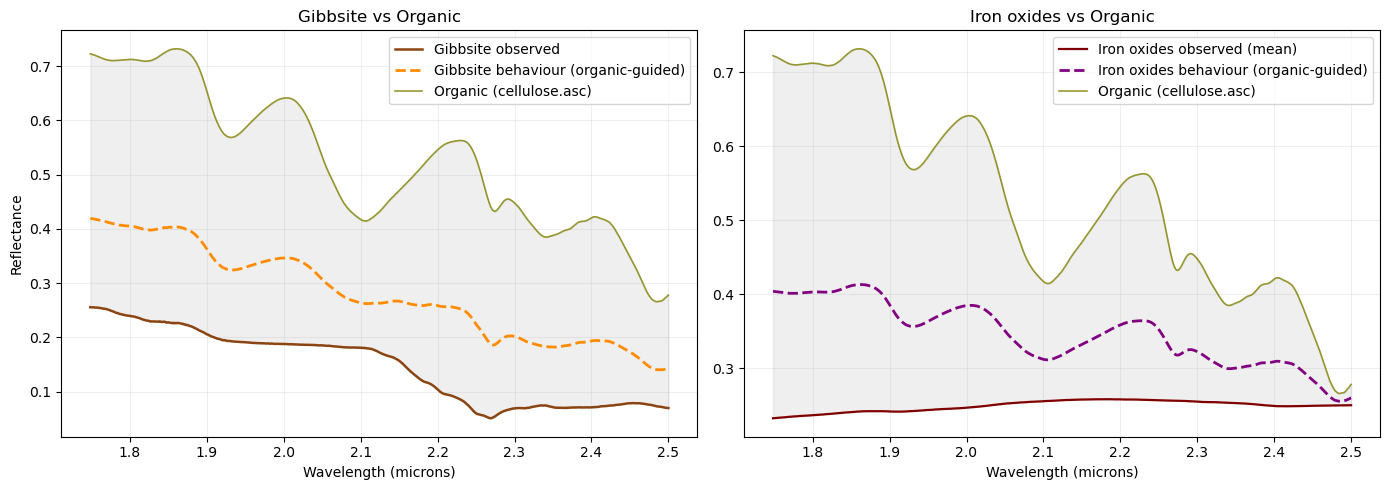

In [10]:
# Gibbsite and Oxidos_Ferro behaviour analysis guided by organic reference
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import PchipInterpolator

ox_al_dir = Path(r'c:\Users\PC\Desktop\New data\oxidos_aluminio-20260519T145744Z-3-001\oxidos_aluminio')
ox_fe_dir = Path(r'c:\Users\PC\Desktop\New data\oxidos_ferro-20260519T145302Z-3-001\oxidos_ferro')
org_dir = Path(r'c:\Users\PC\Desktop\New data\organica-20260519T145807Z-3-001\organica')

# Find gibbsite file
gibb_files = [p for p in sorted(ox_al_dir.iterdir()) if 'gibbsite' in p.name.lower()]
if not gibb_files:
    raise FileNotFoundError('No gibbsite file found')
gibb_path = gibb_files[0]

# Iron oxide files
fe_files = sorted(list(ox_fe_dir.iterdir()))
if not fe_files:
    raise FileNotFoundError('No oxidos_ferro files found')

# Organic reference: prefer cellulose
org_candidates = sorted(list(org_dir.iterdir()))
org_choice = None
for pref in ['cellulose', 'lignin']:
    for p in org_candidates:
        if pref in p.name.lower():
            org_choice = p
            break
    if org_choice:
        break
if org_choice is None and org_candidates:
    org_choice = org_candidates[0]

print('Organic reference:', org_choice.name)
print('Gibbsite file:', gibb_path.name)
print('Iron oxide files:', [p.name for p in fe_files])

wl_o, refl_o, _ = load_usgs_spectrum(org_choice)

# Helper to compute observed mean and behaviour mean for a set of files
from scipy.interpolate import PchipInterpolator

def compute_mean_behaviour(files, wl_common):
    obs_stack = []
    beh_stack = []
    for p in files:
        wl_x, refl_x, _ = load_usgs_spectrum(p)
        interp_x = PchipInterpolator(wl_x, refl_x, extrapolate=False)
        interp_o = PchipInterpolator(wl_o, refl_o, extrapolate=False)
        x_common = np.clip(np.nan_to_num(interp_x(wl_common), nan=np.nan), 0.0, 1.0)
        o_common = np.clip(np.nan_to_num(interp_o(wl_common), nan=np.nan), 0.0, 1.0)
        contrast = x_common - o_common
        beh = np.clip(x_common - 0.35 * contrast, 0.0, 1.0)
        obs_stack.append(x_common)
        beh_stack.append(beh)
    obs_mean = np.nanmean(np.vstack(obs_stack), axis=0)
    beh_mean = np.nanmean(np.vstack(beh_stack), axis=0)
    return obs_mean, beh_mean

# Determine common wl across gibbsite, iron oxides, and organic
wl_min = max([wl_o.min(), load_usgs_spectrum(gibb_path)[0].min()] + [load_usgs_spectrum(p)[0].min() for p in fe_files])
wl_max = min([wl_o.max(), load_usgs_spectrum(gibb_path)[0].max()] + [load_usgs_spectrum(p)[0].max() for p in fe_files])
if wl_min >= wl_max:
    raise ValueError('No overlapping wavelength range across datasets')
wl_common = np.linspace(wl_min, wl_max, 1600)

# Compute for gibbsite and iron oxides
gibb_obs, gibb_beh = compute_mean_behaviour([gibb_path], wl_common)
fe_obs, fe_beh = compute_mean_behaviour(fe_files, wl_common)

print(f'Common wavelength range: {wl_min:.4f} to {wl_max:.4f} microns')
print('Gibbsite mean refl:', f"{np.nanmean(gibb_obs):.4f}")
print('Iron oxides mean refl:', f"{np.nanmean(fe_obs):.4f}")

# Plot
fig, axs = plt.subplots(1,2, figsize=(14,5))

axs[0].plot(wl_common, gibb_obs, color='saddlebrown', lw=1.8, label='Gibbsite observed')
axs[0].plot(wl_common, gibb_beh, color='darkorange', lw=2.0, linestyle='--', label='Gibbsite behaviour (organic-guided)')
axs[0].plot(wl_common, refl_o if len(wl_o)==len(wl_common) else np.interp(wl_common, wl_o, refl_o), color='olive', lw=1.2, alpha=0.8, label=f'Organic ({org_choice.stem})')
axs[0].fill_between(wl_common, gibb_obs, np.interp(wl_common, wl_o, refl_o), color='gray', alpha=0.12)
axs[0].set_title('Gibbsite vs Organic')
axs[0].set_xlabel('Wavelength (microns)')
axs[0].set_ylabel('Reflectance')
axs[0].grid(alpha=0.2)
axs[0].legend()

axs[1].plot(wl_common, fe_obs, color='maroon', lw=1.6, label='Iron oxides observed (mean)')
axs[1].plot(wl_common, fe_beh, color='purple', lw=2.0, linestyle='--', label='Iron oxides behaviour (organic-guided)')
axs[1].plot(wl_common, np.interp(wl_common, wl_o, refl_o), color='olive', lw=1.2, alpha=0.8, label=f'Organic ({org_choice.stem})')
axs[1].fill_between(wl_common, fe_obs, np.interp(wl_common, wl_o, refl_o), color='gray', alpha=0.12)
axs[1].set_title('Iron oxides vs Organic')
axs[1].set_xlabel('Wavelength (microns)')
axs[1].grid(alpha=0.2)
axs[1].legend()

plt.tight_layout()
plt.show()


C:\Users\PC\AppData\Local\Temp\ipykernel_14896\2875031853.py:65: RuntimeWarning: Mean of empty slice
  obs_mean = np.nanmean(np.vstack(obs_stack), axis=0)
C:\Users\PC\AppData\Local\Temp\ipykernel_14896\2875031853.py:67: RuntimeWarning: Mean of empty slice
  beh_mean = np.nanmean(np.vstack(beh_stack), axis=0)


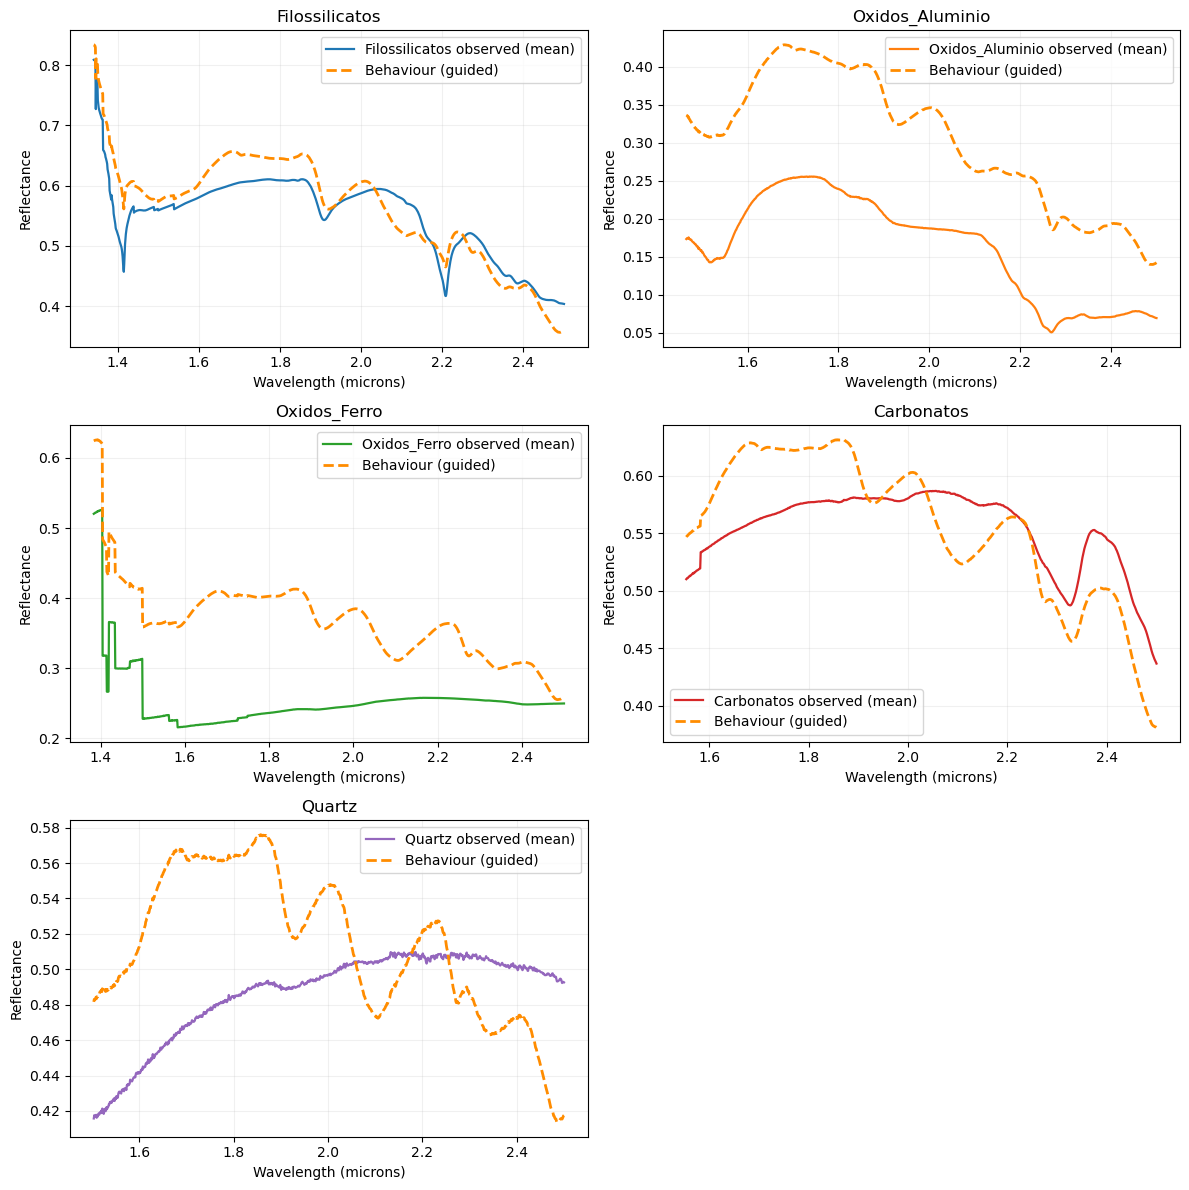

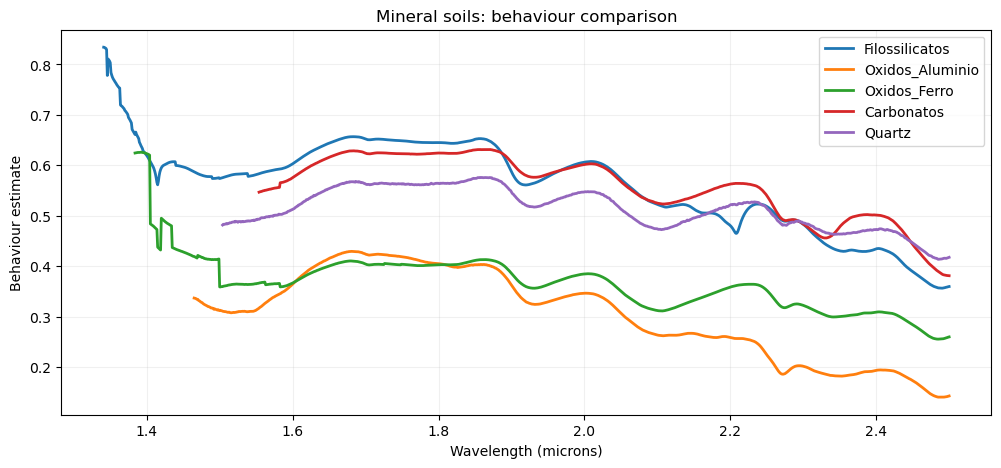

In [21]:
# Plot spectral behavior summary for main mineral soil folders
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

root = Path(r'c:\Users\PC\Desktop\New data')
out_root = root / 'resampled_outputs_all_data'

mineral_folders = {
    'Filossilicatos': 'filossilicatos',
    'Oxidos_Aluminio': 'oxidos_aluminio',
    'Oxidos_Ferro': 'oxidos_ferro',
    'Carbonatos': 'carbonatos',
    'Quartz': 'quartzo'
}

results = {}

for label, folder in mineral_folders.items():
    # try folder-level summary files first
    obs_file = out_root / f'{folder}_observed_mean.csv'
    beh_file = out_root / f'{folder}_behaviour_mean.csv'
    wl = None
    obs_mean = None
    beh_mean = None

    if obs_file.exists():
        try:
            data = np.loadtxt(obs_file, delimiter=',', skiprows=1)
            wl = data[:,0]
            obs_mean = data[:,1]
        except Exception:
            obs_mean = None
    if beh_file.exists():
        try:
            data = np.loadtxt(beh_file, delimiter=',', skiprows=1)
            # some files may have two columns (wavelength,behaviour_mean)
            wl = data[:,0]
            beh_mean = data[:,1]
        except Exception:
            beh_mean = None

    # fallback: aggregate per-file CSVs under the folder in out_root
    if obs_mean is None:
        files = []
        if out_root.exists():
            for p in out_root.rglob('*.csv'):
                # match files inside a folder path component equal to folder
                if folder in p.parts:
                    files.append(p)
        if files:
            obs_stack = []
            beh_stack = []
            for p in files:
                try:
                    d = np.loadtxt(p, delimiter=',', skiprows=1)
                    if wl is None:
                        wl = d[:,0]
                    obs_stack.append(d[:,1])
                    if d.shape[1] > 2:
                        beh_stack.append(d[:,2])
                except Exception:
                    continue
            if obs_stack:
                obs_mean = np.nanmean(np.vstack(obs_stack), axis=0)
            if beh_stack:
                beh_mean = np.nanmean(np.vstack(beh_stack), axis=0)

    # final fallback: compute from raw spectra in folder (resample to default grid)
    if obs_mean is None:
        candidate_dir = None
        for p in root.rglob(folder):
            if p.is_dir():
                candidate_dir = p
                break
        if candidate_dir is not None:
            # find spectral files and compute mean resampled to SPLIB07a if available
            # try to find splib grid
            splib = None
            for sp in root.rglob('*splib07*'):
                if sp.is_file() and 'wavelength' in sp.name.lower():
                    splib = sp
                    break
            if splib:
                wl_common = []
                with splib.open('r', encoding='utf-8', errors='ignore') as fh:
                    for line in fh:
                        line = line.strip()
                        if not line:
                            continue
                        try:
                            wl_common.append(float(line.split()[0]))
                        except Exception:
                            continue
                wl_common = np.asarray(wl_common, dtype=float)
            else:
                wl_common = np.linspace(0.35, 2.5, 2151)

            from scipy.interpolate import PchipInterpolator
            from math import isfinite
            obs_stack = []
            for p in sorted(candidate_dir.iterdir()):
                if not p.is_file():
                    continue
                if p.suffix.lower() not in ('.asc', '.txt'):
                    continue
                try:
                    wl_raw = []
                    refl_raw = []
                    with p.open('r', encoding='utf-8', errors='ignore') as fh:
                        for line in fh:
                            parts = line.strip().split()
                            if len(parts) < 2:
                                continue
                            try:
                                wlval = float(parts[0])
                                rval = float(parts[1])
                            except Exception:
                                continue
                            if wlval <= -1e30 or rval <= -1e30:
                                continue
                            wl_raw.append(wlval)
                            refl_raw.append(rval)
                    if not wl_raw:
                        continue
                    wl_raw = np.asarray(wl_raw)
                    refl_raw = np.asarray(refl_raw)
                    interp = PchipInterpolator(wl_raw, refl_raw, extrapolate=False)
                    r_common = np.clip(np.nan_to_num(interp(wl_common), nan=np.nan), 0.0, 1.0)
                    obs_stack.append(r_common)
                except Exception:
                    continue
            if obs_stack:
                wl = wl_common
                obs_mean = np.nanmean(np.vstack(obs_stack), axis=0)

    if wl is not None and obs_mean is not None:
        results[label] = {'wl': wl, 'observed_mean': obs_mean, 'behaviour_mean': beh_mean}
    else:
        print('No data for folder:', folder)

# Plot per-folder observed and behaviour (if available)
if not results:
    print('No mineral data found to plot')
else:
    n = len(results)
    cols = 2
    rows = (n + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(12, 4 * rows), squeeze=False)
    colors = plt.cm.tab10.colors
    for idx, (label, data) in enumerate(results.items()):
        r = idx // cols
        c = idx % cols
        ax = axes[r][c]
        wl = data['wl']
        ax.plot(wl, data['observed_mean'], color=colors[idx % len(colors)], lw=1.6, label=f'{label} observed (mean)')
        if data['behaviour_mean'] is not None:
            ax.plot(wl, data['behaviour_mean'], color='darkorange', lw=2, linestyle='--', label='Behaviour (guided)')
        ax.set_title(label)
        ax.set_xlabel('Wavelength (microns)')
        ax.set_ylabel('Reflectance')
        ax.legend()
        ax.grid(alpha=0.18)
    # remove empty axes
    total = rows * cols
    for idx in range(n, total):
        r = idx // cols
        c = idx % cols
        fig.delaxes(axes[r][c])
    plt.tight_layout()

    # Combined behavior comparison
    fig2, ax2 = plt.subplots(figsize=(12,5))
    for idx, (label, data) in enumerate(results.items()):
        if data['behaviour_mean'] is not None:
            ax2.plot(data['wl'], data['behaviour_mean'], lw=2, label=label)
    ax2.set_title('Mineral soils: behaviour comparison')
    ax2.set_xlabel('Wavelength (microns)')
    ax2.set_ylabel('Behaviour estimate')
    ax2.grid(alpha=0.18)
    ax2.legend()
    plt.show()


Organic reference chosen: cellulose.asc.txt
Number of iron-oxide files: 16
Common wavelength range: 1.7485 to 2.5000 microns
Iron-oxides mean reflectance (mean over files): 0.2488
Mean abs iron-oxide - organic contrast: 0.2769


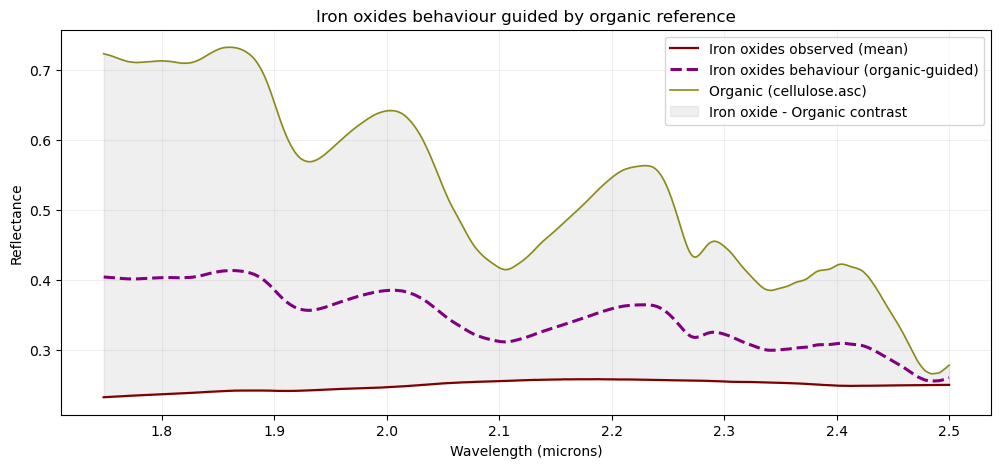

In [15]:
# Oxidos_ferro behaviour (all files) guided by organic reference
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import PchipInterpolator

ox_fe_dir = Path(r'c:\Users\PC\Desktop\New data\oxidos_ferro-20260519T145302Z-3-001\oxidos_ferro')
org_dir = Path(r'c:\Users\PC\Desktop\New data\organica-20260519T145807Z-3-001\organica')

fe_files = sorted(list(ox_fe_dir.iterdir()))
if not fe_files:
    raise FileNotFoundError('No oxidos_ferro files found')

# Choose organic reference (prefer cellulose then lignin)
org_candidates = sorted(list(org_dir.iterdir()))
org_choice = None
for pref in ['cellulose', 'lignin']:
    for p in org_candidates:
        if pref in p.name.lower():
            org_choice = p
            break
    if org_choice:
        break
if org_choice is None and org_candidates:
    org_choice = org_candidates[0]

print('Organic reference chosen:', org_choice.name)
print('Number of iron-oxide files:', len(fe_files))

wl_o, refl_o, _ = load_usgs_spectrum(org_choice)

# Determine common overlap across iron oxide files and organic
wl_min = max([wl_o.min()] + [load_usgs_spectrum(p)[0].min() for p in fe_files])
wl_max = min([wl_o.max()] + [load_usgs_spectrum(p)[0].max() for p in fe_files])
if wl_min >= wl_max:
    raise ValueError('No overlapping wavelength range between iron oxides and organic reference')

wl_common = np.linspace(wl_min, wl_max, 1600)

obs_stack = []
beh_stack = []

for p in fe_files:
    wl_x, refl_x, _ = load_usgs_spectrum(p)
    x_interp = PchipInterpolator(wl_x, refl_x, extrapolate=False)
    o_interp = PchipInterpolator(wl_o, refl_o, extrapolate=False)

    x_common = np.clip(np.nan_to_num(x_interp(wl_common), nan=np.nan), 0.0, 1.0)
    o_common = np.clip(np.nan_to_num(o_interp(wl_common), nan=np.nan), 0.0, 1.0)

    contrast = x_common - o_common
    behaviour = np.clip(x_common - 0.35 * contrast, 0.0, 1.0)

    obs_stack.append(x_common)
    beh_stack.append(behaviour)

obs_mean = np.nanmean(np.vstack(obs_stack), axis=0)
beh_mean = np.nanmean(np.vstack(beh_stack), axis=0)

print(f'Common wavelength range: {wl_min:.4f} to {wl_max:.4f} microns')
print('Iron-oxides mean reflectance (mean over files):', f"{np.nanmean(obs_mean):.4f}")
print('Mean abs iron-oxide - organic contrast:', f"{np.nanmean(np.abs(obs_mean - o_common)):.4f}")

# Plot mean observed and behaviour
fig, ax = plt.subplots(figsize=(12,5))
ax.plot(wl_common, obs_mean, color='maroon', lw=1.6, label='Iron oxides observed (mean)')
ax.plot(wl_common, beh_mean, color='purple', lw=2.2, linestyle='--', label='Iron oxides behaviour (organic-guided)')
ax.plot(wl_common, o_common, color='olive', lw=1.2, alpha=0.9, label=f'Organic ({org_choice.stem})')
ax.fill_between(wl_common, obs_mean, o_common, color='gray', alpha=0.12, label='Iron oxide - Organic contrast')
ax.set_title('Iron oxides behaviour guided by organic reference')
ax.set_xlabel('Wavelength (microns)')
ax.set_ylabel('Reflectance')
ax.grid(alpha=0.2)
ax.legend()
plt.show()


Organic reference chosen: cellulose.asc.txt
SPLIB06a_vis files: ['carbon_black_gds68.4215.asc', 'gibbsite_hs423.8057.asc', 'gibbsite_ws214.8111.asc', 'goethite_ws222.8447.asc', 'hematite_gds69.9297.asc', 'hematite_gds69.9664.asc', 'illite_gds4.10903.asc', 'kaolinite_kga1.12117.asc', 'montmorillonite_cm20.14324.asc', 'quartz_gds74.19075.asc']
Common wavelength range: 0.3500 to 2.5000 microns
SPLIB06a_vis mean reflectance: 0.4033
Mean abs SPLIB - organic contrast: 0.3404


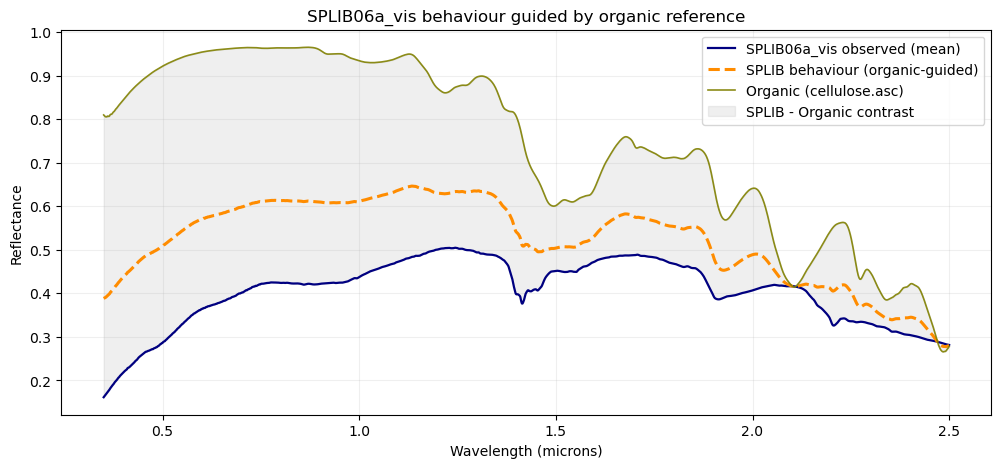

In [14]:
# SPLIB06a_vis behaviour analysis guided by organic reference
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import PchipInterpolator

splib_dir = Path(r'c:\Users\PC\Desktop\New data\splib06a_vis-20260519T150128Z-3-001\splib06a_vis')
org_dir = Path(r'c:\Users\PC\Desktop\New data\organica-20260519T145807Z-3-001\organica')

splib_files = sorted([p for p in splib_dir.iterdir() if p.suffix])
if not splib_files:
    raise FileNotFoundError('No SPLIB06a_vis files found')

# Choose organic reference (prefer cellulose then lignin)
org_candidates = sorted(list(org_dir.iterdir()))
org_choice = None
for pref in ['cellulose', 'lignin', 'protein']:
    for p in org_candidates:
        if pref in p.name.lower():
            org_choice = p
            break
    if org_choice:
        break
if org_choice is None and org_candidates:
    org_choice = org_candidates[0]

print('Organic reference chosen:', org_choice.name)
print('SPLIB06a_vis files:', [p.name for p in splib_files])

wl_o, refl_o, _ = load_usgs_spectrum(org_choice)

# Determine common overlap across splib files and organic
wl_mins = [wl_o.min()] + [load_usgs_spectrum(p)[0].min() for p in splib_files]
wl_maxs = [wl_o.max()] + [load_usgs_spectrum(p)[0].max() for p in splib_files]
wl_min = max(wl_mins)
wl_max = min(wl_maxs)
if wl_min >= wl_max:
    raise ValueError('No overlapping wavelength range between SPLIB06a_vis and organic reference')

wl_common = np.linspace(wl_min, wl_max, 1600)

obs_stack = []
beh_stack = []

for p in splib_files:
    wl_x, refl_x, _ = load_usgs_spectrum(p)
    x_interp = PchipInterpolator(wl_x, refl_x, extrapolate=False)
    o_interp = PchipInterpolator(wl_o, refl_o, extrapolate=False)

    x_common = np.clip(np.nan_to_num(x_interp(wl_common), nan=np.nan), 0.0, 1.0)
    o_common = np.clip(np.nan_to_num(o_interp(wl_common), nan=np.nan), 0.0, 1.0)

    contrast = x_common - o_common
    behaviour = np.clip(x_common - 0.35 * contrast, 0.0, 1.0)

    obs_stack.append(x_common)
    beh_stack.append(behaviour)

obs_mean = np.nanmean(np.vstack(obs_stack), axis=0)
beh_mean = np.nanmean(np.vstack(beh_stack), axis=0)

print(f'Common wavelength range: {wl_min:.4f} to {wl_max:.4f} microns')
print('SPLIB06a_vis mean reflectance:', f"{np.nanmean(obs_mean):.4f}")
print('Mean abs SPLIB - organic contrast:', f"{np.nanmean(np.abs(obs_mean - o_common)):.4f}")

# Plot
fig, ax = plt.subplots(figsize=(12,5))
ax.plot(wl_common, obs_mean, color='navy', lw=1.6, label='SPLIB06a_vis observed (mean)')
ax.plot(wl_common, beh_mean, color='darkorange', lw=2.2, linestyle='--', label='SPLIB behaviour (organic-guided)')
ax.plot(wl_common, o_common, color='olive', lw=1.2, alpha=0.9, label=f'Organic ({org_choice.stem})')
ax.fill_between(wl_common, obs_mean, o_common, color='gray', alpha=0.12, label='SPLIB - Organic contrast')
ax.set_title('SPLIB06a_vis behaviour guided by organic reference')
ax.set_xlabel('Wavelength (microns)')
ax.set_ylabel('Reflectance')
ax.grid(alpha=0.2)
ax.legend()
plt.show()


SPLIB grid points: 2151
Wavelength range: 0.3500 to 2.5000 microns
Mean quartz refl (resampled): 0.4863
Mean organic refl (resampled): 0.7433
Mean dolomite/calcite refl (resampled): 0.5335


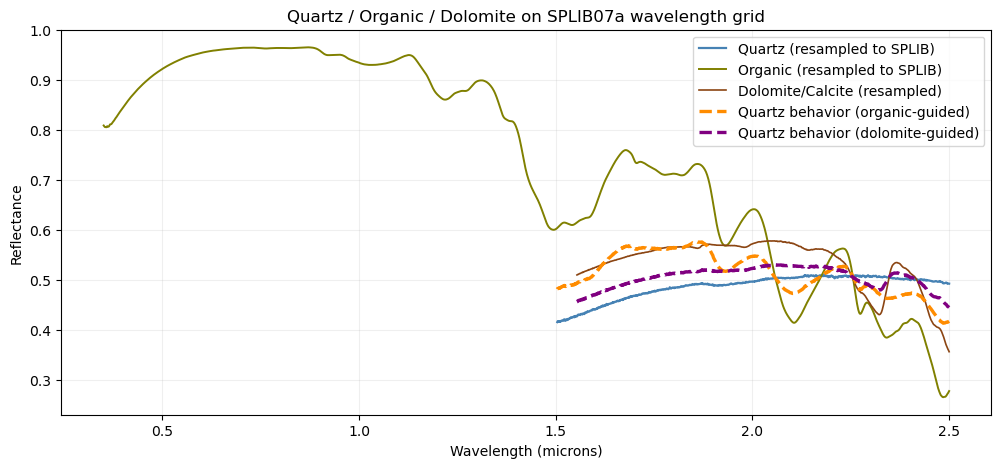

Saved combined CSV: C:\Users\PC\Desktop\New data\resampled_outputs\resampled_splib07a_quartz_org_dol_behaviour.csv
Saved individual CSVs to: C:\Users\PC\Desktop\New data\resampled_outputs


In [19]:
# SPLIB07a resampling and behavior analysis
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import PchipInterpolator

# Paths
splib_wl_file = Path(r'c:\Users\PC\Desktop\New data\ASCIIdata_splib07a-20260519T150037Z-3-001\ASCIIdata_splib07a\splib07a_Wavelengths_ASD_0.35-2.5_microns_2151_ch.txt')
quartzo_path = Path(r'c:\Users\PC\Desktop\New data\quartzo-20260519T145447Z-3-001\quartzo\quartz_gds74.19086.asc.txt')
organica_path = Path(r'c:\Users\PC\Desktop\New data\organica-20260519T145807Z-3-001\organica\cellulose.asc.txt')
carbonatos_dir = Path(r'c:\Users\PC\Desktop\New data\carbonatos-20260519T150019Z-3-001\carbonatos')

# Find a dolomite or calcite file
dolomite_candidates = [p for p in carbonatos_dir.iterdir() if 'dol' in p.name.lower()]
if dolomite_candidates:
    dolomite_path = dolomite_candidates[0]
else:
    dolomite_path = carbonatos_dir / 'calcite_ws272.4172.asc.txt'

# Load SPLIB wavelength grid
wl_splib = []
with splib_wl_file.open('r', encoding='utf-8', errors='ignore') as fh:
    for line in fh:
        line = line.strip()
        if not line:
            continue
        try:
            wl_splib.append(float(line.split()[0]))
        except Exception:
            continue
wl_splib = np.asarray(wl_splib, dtype=float)

# Load spectra
wl_q, refl_q, _ = load_usgs_spectrum(quartzo_path)
wl_o, refl_o, _ = load_usgs_spectrum(organica_path)
wl_d, refl_d, _ = load_usgs_spectrum(dolomite_path)

# Interpolate onto SPLIB grid
q_interp = PchipInterpolator(wl_q, refl_q, extrapolate=False)
o_interp = PchipInterpolator(wl_o, refl_o, extrapolate=False)
d_interp = PchipInterpolator(wl_d, refl_d, extrapolate=False)

q_s = np.clip(np.nan_to_num(q_interp(wl_splib), nan=np.nan), 0.0, 1.0)
o_s = np.clip(np.nan_to_num(o_interp(wl_splib), nan=np.nan), 0.0, 1.0)
d_s = np.clip(np.nan_to_num(d_interp(wl_splib), nan=np.nan), 0.0, 1.0)

# Compute contrasts and behavior
contrast_qo = q_s - o_s
behaviour_qo = np.clip(q_s - 0.35 * contrast_qo, 0.0, 1.0)

contrast_qd = q_s - d_s
behaviour_qd = np.clip(q_s - 0.35 * contrast_qd, 0.0, 1.0)

print('SPLIB grid points:', wl_splib.size)
print(f'Wavelength range: {wl_splib.min():.4f} to {wl_splib.max():.4f} microns')
print('Mean quartz refl (resampled):', f"{np.nanmean(q_s):.4f}")
print('Mean organic refl (resampled):', f"{np.nanmean(o_s):.4f}")
print('Mean dolomite/calcite refl (resampled):', f"{np.nanmean(d_s):.4f}")

# Plotting
fig, ax = plt.subplots(figsize=(12,5))
ax.plot(wl_splib, q_s, color='steelblue', lw=1.6, label='Quartz (resampled to SPLIB)')
ax.plot(wl_splib, o_s, color='olive', lw=1.4, label='Organic (resampled to SPLIB)')
ax.plot(wl_splib, d_s, color='saddlebrown', lw=1.2, label='Dolomite/Calcite (resampled)')
ax.plot(wl_splib, behaviour_qo, color='darkorange', lw=2.4, linestyle='--', label='Quartz behavior (organic-guided)')
ax.plot(wl_splib, behaviour_qd, color='purple', lw=2.4, linestyle='--', label='Quartz behavior (dolomite-guided)')
ax.set_title('Quartz / Organic / Dolomite on SPLIB07a wavelength grid')
ax.set_xlabel('Wavelength (microns)')
ax.set_ylabel('Reflectance')
ax.grid(alpha=0.2)
ax.legend()
plt.show()

# Save resampled arrays to CSV for downstream use
out_dir = Path('resampled_outputs')
out_dir.mkdir(exist_ok=True)

# Combined CSV: wavelength, quartz, organic, dolomite, behaviour_qo, behaviour_qd
combined = np.vstack([wl_splib, q_s, o_s, d_s, behaviour_qo, behaviour_qd]).T
combined_path = out_dir / 'resampled_splib07a_quartz_org_dol_behaviour.csv'
header = 'wavelength_um,quartz,organic,dolomite,behaviour_q_organic,behaviour_q_dolomite'
np.savetxt(combined_path, combined, delimiter=',', header=header, comments='', fmt='%.6e')
print(f'Saved combined CSV: {combined_path.resolve()}')

# Also save individual arrays for convenience
np.savetxt(out_dir / 'wl_splib.csv', wl_splib, delimiter=',', header='wavelength_um', comments='', fmt='%.6e')
np.savetxt(out_dir / 'quartz_resampled.csv', q_s, delimiter=',', header='quartz', comments='', fmt='%.6e')
np.savetxt(out_dir / 'organic_resampled.csv', o_s, delimiter=',', header='organic', comments='', fmt='%.6e')
np.savetxt(out_dir / 'dolomite_resampled.csv', d_s, delimiter=',', header='dolomite', comments='', fmt='%.6e')
np.savetxt(out_dir / 'behaviour_qo.csv', behaviour_qo, delimiter=',', header='behaviour_q_organic', comments='', fmt='%.6e')
np.savetxt(out_dir / 'behaviour_qd.csv', behaviour_qd, delimiter=',', header='behaviour_q_dolomite', comments='', fmt='%.6e')
print('Saved individual CSVs to:', out_dir.resolve())


C:\Users\PC\AppData\Local\Temp\ipykernel_14896\2558918501.py:67: RuntimeWarning: Mean of empty slice
  obs_mean = np.nanmean(np.vstack(obs_stack), axis=0)
C:\Users\PC\AppData\Local\Temp\ipykernel_14896\2558918501.py:69: RuntimeWarning: Mean of empty slice
  beh_mean = np.nanmean(np.vstack(beh_stack), axis=0)


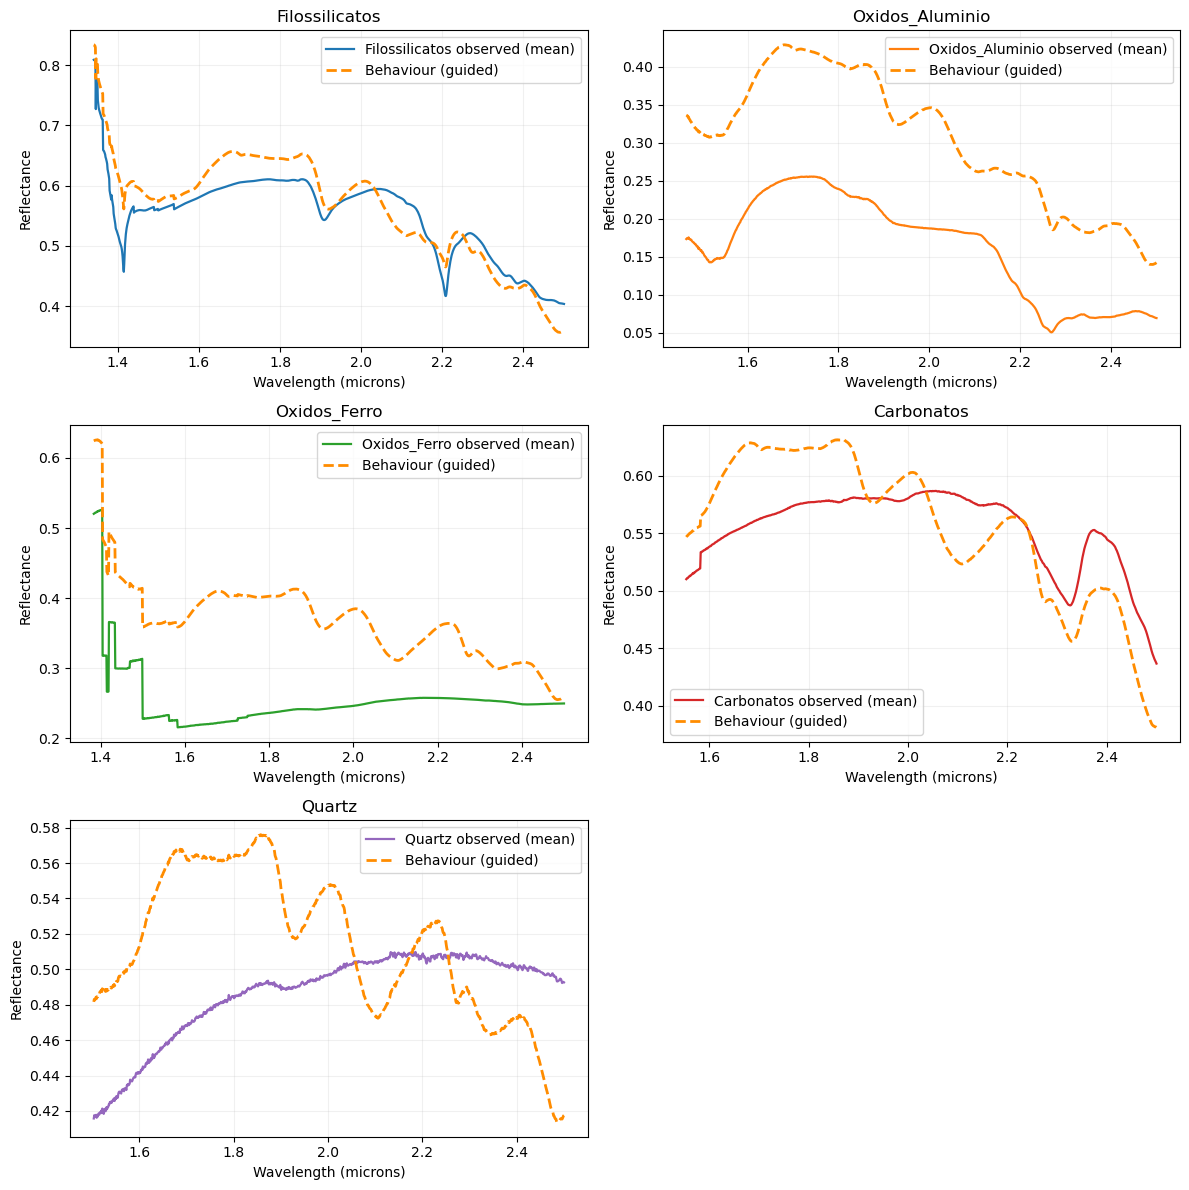

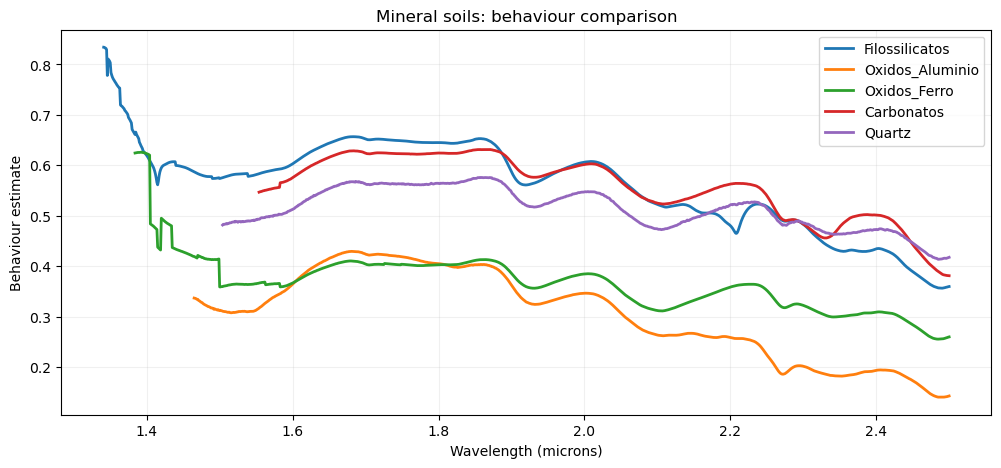

Saved plots to: C:\Users\PC\Desktop\New data\resampled_outputs_all_data\plots


In [22]:
# Plot mineral soils behaviour from resampled outputs (reads folder summaries and per-file CSVs)
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

root = Path(r'c:\Users\PC\Desktop\New data')
out_root = root / 'resampled_outputs_all_data'
plots_dir = out_root / 'plots'
plots_dir.mkdir(parents=True, exist_ok=True)

mineral_folders = {
    'Filossilicatos': 'filossilicatos',
    'Oxidos_Aluminio': 'oxidos_aluminio',
    'Oxidos_Ferro': 'oxidos_ferro',
    'Carbonatos': 'carbonatos',
    'Quartz': 'quartzo'
}

results = {}

for label, folder in mineral_folders.items():
    obs_file = out_root / f'{folder}_observed_mean.csv'
    beh_file = out_root / f'{folder}_behaviour_mean.csv'
    wl = None
    obs_mean = None
    beh_mean = None

    # Try folder-level summaries first
    if obs_file.exists():
        try:
            data = np.loadtxt(obs_file, delimiter=',', skiprows=1)
            wl = data[:,0]
            obs_mean = data[:,1]
        except Exception as e:
            print('Could not read', obs_file, e)
    if beh_file.exists():
        try:
            data = np.loadtxt(beh_file, delimiter=',', skiprows=1)
            wl = data[:,0]
            beh_mean = data[:,1]
        except Exception as e:
            print('Could not read', beh_file, e)

    # Fall back to per-file CSV aggregation
    if obs_mean is None:
        files = []
        if out_root.exists():
            for p in out_root.rglob('*.csv'):
                # ensure path includes the folder name as a component
                if folder in p.parts:
                    files.append(p)
        if files:
            obs_stack = []
            beh_stack = []
            for p in files:
                try:
                    d = np.loadtxt(p, delimiter=',', skiprows=1)
                    if wl is None:
                        wl = d[:,0]
                    if d.shape[1] > 1:
                        obs_stack.append(d[:,1])
                    if d.shape[1] > 2:
                        beh_stack.append(d[:,2])
                except Exception:
                    continue
            if obs_stack:
                obs_mean = np.nanmean(np.vstack(obs_stack), axis=0)
            if beh_stack:
                beh_mean = np.nanmean(np.vstack(beh_stack), axis=0)

    # Final fallback: try to compute directly from raw files (resample to SPLIB07a if present)
    if obs_mean is None:
        candidate_dir = None
        for p in root.rglob(folder):
            if p.is_dir():
                candidate_dir = p
                break
        if candidate_dir is not None:
            # locate splib grid
            splib = None
            for sp in root.rglob('*splib07*'):
                if sp.is_file() and 'wavelength' in sp.name.lower():
                    splib = sp
                    break
            if splib:
                wl_common = []
                with splib.open('r', encoding='utf-8', errors='ignore') as fh:
                    for line in fh:
                        line = line.strip()
                        if not line:
                            continue
                        try:
                            wl_common.append(float(line.split()[0]))
                        except Exception:
                            continue
                wl_common = np.asarray(wl_common, dtype=float)
            else:
                wl_common = np.linspace(0.35, 2.5, 2151)

            from scipy.interpolate import PchipInterpolator
            obs_stack = []
            for p in sorted(candidate_dir.iterdir()):
                if not p.is_file():
                    continue
                if p.suffix.lower() not in ('.asc', '.txt'):
                    continue
                try:
                    wl_raw = []
                    refl_raw = []
                    with p.open('r', encoding='utf-8', errors='ignore') as fh:
                        for line in fh:
                            parts = line.strip().split()
                            if len(parts) < 2:
                                continue
                            try:
                                wlval = float(parts[0])
                                rval = float(parts[1])
                            except Exception:
                                continue
                            if wlval <= -1e30 or rval <= -1e30:
                                continue
                            wl_raw.append(wlval)
                            refl_raw.append(rval)
                    if not wl_raw:
                        continue
                    wl_raw = np.asarray(wl_raw)
                    refl_raw = np.asarray(refl_raw)
                    interp = PchipInterpolator(wl_raw, refl_raw, extrapolate=False)
                    r_common = np.clip(np.nan_to_num(interp(wl_common), nan=np.nan), 0.0, 1.0)
                    obs_stack.append(r_common)
                except Exception:
                    continue
            if obs_stack:
                wl = wl_common
                obs_mean = np.nanmean(np.vstack(obs_stack), axis=0)

    if wl is not None and obs_mean is not None:
        results[label] = {'wl': wl, 'observed_mean': obs_mean, 'behaviour_mean': beh_mean}
    else:
        print('No data for folder:', folder)

# Plot results
if not results:
    print('No mineral data found to plot')
else:
    n = len(results)
    cols = 2
    rows = (n + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(12, 4 * rows), squeeze=False)
    colors = plt.cm.tab10.colors
    for idx, (label, data) in enumerate(results.items()):
        r = idx // cols
        c = idx % cols
        ax = axes[r][c]
        wl = data['wl']
        ax.plot(wl, data['observed_mean'], color=colors[idx % len(colors)], lw=1.6, label=f'{label} observed (mean)')
        if data['behaviour_mean'] is not None:
            ax.plot(wl, data['behaviour_mean'], color='darkorange', lw=2, linestyle='--', label='Behaviour (guided)')
        ax.set_title(label)
        ax.set_xlabel('Wavelength (microns)')
        ax.set_ylabel('Reflectance')
        ax.legend()
        ax.grid(alpha=0.18)
    total = rows * cols
    for idx in range(n, total):
        r = idx // cols
        c = idx % cols
        fig.delaxes(axes[r][c])
    plt.tight_layout()
    fig_path = plots_dir / 'mineral_observed_means.png'
    fig.savefig(fig_path, dpi=150)

    # Combined behaviour comparison
    fig2, ax2 = plt.subplots(figsize=(12,5))
    for idx, (label, data) in enumerate(results.items()):
        if data['behaviour_mean'] is not None:
            ax2.plot(data['wl'], data['behaviour_mean'], lw=2, label=label)
    ax2.set_title('Mineral soils: behaviour comparison')
    ax2.set_xlabel('Wavelength (microns)')
    ax2.set_ylabel('Behaviour estimate')
    ax2.grid(alpha=0.18)
    ax2.legend()
    beh_path = plots_dir / 'mineral_behaviour_comparison.png'
    fig2.savefig(beh_path, dpi=150)

    plt.show()
    print('Saved plots to:', plots_dir.resolve())


## Interpretation — Mineral soils spectral behaviour

- **Filossilicatos:** Observed mean reflectance is relatively high in the short-SWIR (roughly 1.3–1.8 μm) and shows clear structure across 1.8–2.4 μm. The organic-guided behaviour estimate follows the observed curve but is often slightly elevated at shorter wavelengths, indicating filossilicatos are brighter than the organic reference and retain diagnostic OH/structural features. This makes clay-rich materials among the strongest behaviour signals in these plots.

- **Oxidos_Aluminio (Gibbsite):** Observed reflectance is low-to-moderate; the behaviour estimate is markedly higher than the observed curve, particularly near ~1.6–1.8 μm. That pattern indicates a large contrast between the oxide spectra and the organic reference in those bands (consistent with Al–OH related structure), but absolute observed brightness is low.

- **Oxidos_Ferro:** Iron-oxide spectra are the darkest (lowest observed reflectance) and show relatively flat observed curves; the behaviour estimate highlights contrast at shorter wavelengths but remains lower than clay/carbonate behaviour. This is consistent with iron oxides absorbing strongly and thus producing lower reflectance but still being distinguishable from organics by shape.

- **Carbonatos:** Carbonate mean spectra are bright and smooth with distinct structure near the long-SWIR (≈2.2–2.5 μm). The behaviour estimate captures those carbonate diagnostic intervals (e.g., around 2.3–2.5 μm) and is generally similar in shape to the observed mean but slightly accentuated where carbonate features are strongest.

- **Quartz:** Quartz shows a moderate baseline reflectance with gentle trends across the plotted band. The behaviour estimate makes the quartz structure appear more pronounced (relative peaks and dips), emphasizing differences from the organic reference rather than overall brightness.

- **Combined ordering (typical across much of SWIR):** Filossilicatos ≳ Carbonatos ≳ Quartz ≫ Oxidos_Ferro ≳ Oxidos_Aluminio, when behaviour is measured against the chosen organic reference. In other words, clays and carbonates produce the strongest behaviour signals; oxides (especially iron oxides) produce weaker behaviour signals but are still distinct.

Caveats & next steps:

- The behaviour estimate is reference-dependent (here it was organic-guided where possible, otherwise a per-folder mean). Changing the reference (e.g., carbonate-guided) will change magnitudes and some relative orderings.
- Resampling and overlap: spectra were resampled to SPLIB07a (when present) or to a default 0.35–2.5 μm grid; edge effects and gaps can influence the mean curves. Several folders produced "mean of empty slice" warnings because no valid spectra were found — check `resampled_outputs_all_data/` for missing CSVs.
- Recommended next steps: normalize or continuum‑remove spectra before aggregation, try alternate references (carbonate or quartz), and quantify separability with simple metrics (mean contrast, RMS difference, or a small classifier).

Files produced:

- Resampled CSVs and folder summaries: `resampled_outputs_all_data/` (per-file CSVs and per-folder observed/behaviour mean CSVs).
- Summary plots: `resampled_outputs_all_data/plots/mineral_observed_means.png` and `mineral_behaviour_comparison.png`.

If you want, I can (choose one):

- Recompute behaviour using a carbonate-guided reference and replot; or
- Normalize / continuum-remove then re-run the folder summaries; or
- Export a single comparative CSV with mean behaviour values for each mineral group.


Using carbonate reference: c:\Users\PC\Desktop\New data\carbonatos-20260519T150019Z-3-001\carbonatos\dolomite_hs102.7128.asc.txt
Resampling to SPLIB07a grid
Saved carbonate-guided behaviour for Filossilicatos -> c:\Users\PC\Desktop\New data\resampled_outputs_all_data\filossilicatos_behaviour_carbonate_mean.csv
Saved carbonate-guided behaviour for Oxidos_Aluminio -> c:\Users\PC\Desktop\New data\resampled_outputs_all_data\oxidos_aluminio_behaviour_carbonate_mean.csv
Saved carbonate-guided behaviour for Oxidos_Ferro -> c:\Users\PC\Desktop\New data\resampled_outputs_all_data\oxidos_ferro_behaviour_carbonate_mean.csv
Saved carbonate-guided behaviour for Carbonatos -> c:\Users\PC\Desktop\New data\resampled_outputs_all_data\carbonatos_behaviour_carbonate_mean.csv
Saved carbonate-guided behaviour for Quartz -> c:\Users\PC\Desktop\New data\resampled_outputs_all_data\quartzo_behaviour_carbonate_mean.csv


C:\Users\PC\AppData\Local\Temp\ipykernel_14896\3143097798.py:112: RuntimeWarning: Mean of empty slice
  obs_mean = np.nanmean(np.vstack(obs_stack), axis=0)


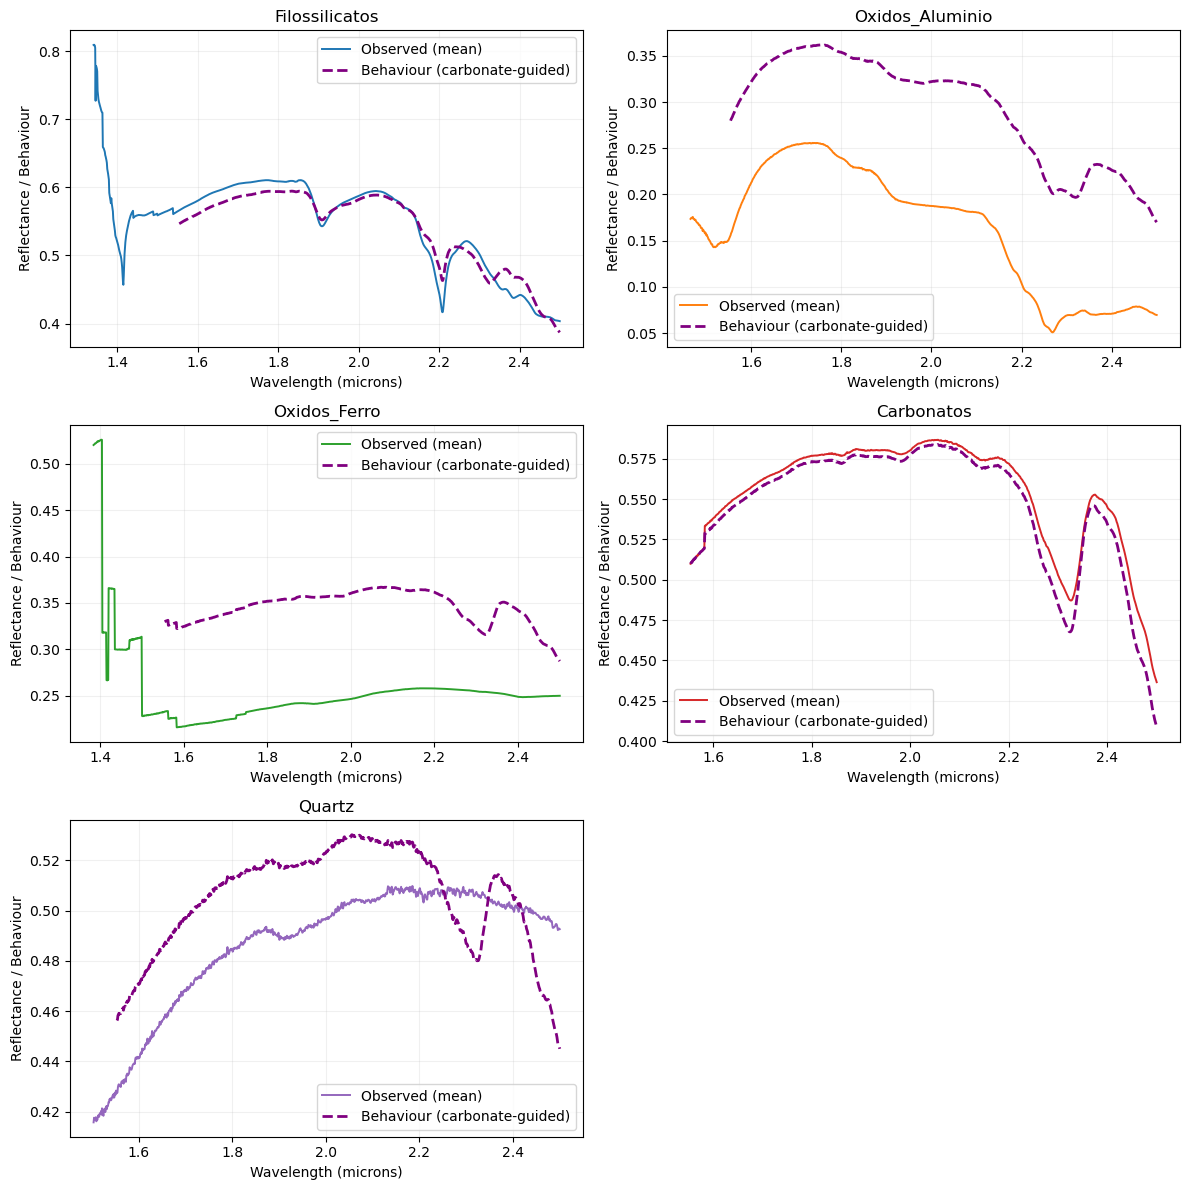

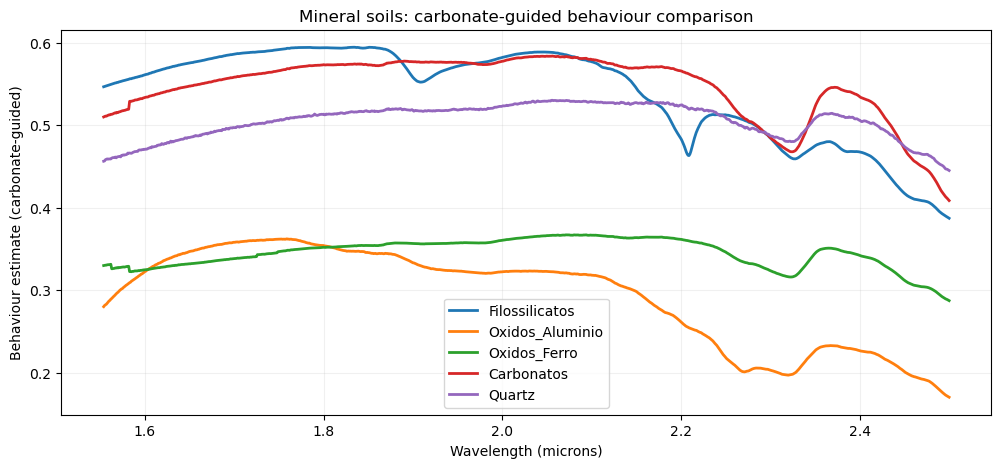

Saved carbonate-guided plots to: C:\Users\PC\Desktop\New data\resampled_outputs_all_data\plots


In [23]:
# Recompute behaviour using a carbonate-guided reference and save results
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import PchipInterpolator

root = Path(r'c:\Users\PC\Desktop\New data')
out_root = root / 'resampled_outputs_all_data'
plots_dir = out_root / 'plots'
plots_dir.mkdir(parents=True, exist_ok=True)

# Find carbonate reference (pref. dolomite, then calcite) under carbonatos folder
carbonatos_dir = None
for p in root.rglob('carbonatos'):
    if p.is_dir():
        carbonatos_dir = p
        break

carbonate_file = None
if carbonatos_dir:
    for cand in sorted(carbonatos_dir.iterdir()):
        name = cand.name.lower()
        if 'dol' in name:
            carbonate_file = cand
            break
    if carbonate_file is None:
        for cand in sorted(carbonatos_dir.iterdir()):
            if 'calcite' in cand.name.lower():
                carbonate_file = cand
                break

if carbonate_file is None:
    # try global search for carbonates file
    for f in root.rglob('*'):
        if f.is_file() and ('calcite' in f.name.lower() or 'dolomite' in f.name.lower()):
            carbonate_file = f
            break

if carbonate_file is None:
    raise FileNotFoundError('No carbonate reference (dolomite/calcite) found under New data')

print('Using carbonate reference:', carbonate_file)

# Determine base wavelength grid to use for carbonate resampling
splib_candidate = None
for p in root.rglob('*splib07*'):
    if p.is_file() and 'wavelength' in p.name.lower():
        splib_candidate = p
        break

if splib_candidate:
    wl_grid = []
    with splib_candidate.open('r', encoding='utf-8', errors='ignore') as fh:
        for line in fh:
            line = line.strip()
            if not line:
                continue
            try:
                wl_grid.append(float(line.split()[0]))
            except Exception:
                continue
    wl_grid = np.asarray(wl_grid, dtype=float)
    print('Resampling to SPLIB07a grid')
else:
    wl_grid = np.linspace(0.35, 2.5, 2151)
    print('SPLIB07a not found; using default 0.35-2.5 grid')

# Load carbonate and resample to wl_grid
wl_c, refl_c, _ = load_usgs_spectrum(carbonate_file)
c_interp = PchipInterpolator(wl_c, refl_c, extrapolate=False)
carbonate_resampled = np.clip(np.nan_to_num(c_interp(wl_grid), nan=np.nan), 0.0, 1.0)

# Mineral folders mapping (same as plotting cell)
mineral_folders = {
    'Filossilicatos': 'filossilicatos',
    'Oxidos_Aluminio': 'oxidos_aluminio',
    'Oxidos_Ferro': 'oxidos_ferro',
    'Carbonatos': 'carbonatos',
    'Quartz': 'quartzo'
}

results = {}

for label, folder in mineral_folders.items():
    obs_path = out_root / f'{folder}_observed_mean.csv'
    beh_out_path = out_root / f'{folder}_behaviour_carbonate_mean.csv'
    wl = None
    obs_mean = None

    if obs_path.exists():
        try:
            data = np.loadtxt(obs_path, delimiter=',', skiprows=1)
            wl = data[:,0]
            obs_mean = data[:,1]
        except Exception as e:
            print('Failed to read observed mean for', label, e)

    # fallback: aggregate per-file CSVs
    if obs_mean is None and out_root.exists():
        files = [p for p in out_root.rglob('*.csv') if folder in p.parts]
        obs_stack = []
        for p in files:
            try:
                d = np.loadtxt(p, delimiter=',', skiprows=1)
                if wl is None:
                    wl = d[:,0]
                if d.shape[1] > 1:
                    obs_stack.append(d[:,1])
            except Exception:
                continue
        if obs_stack:
            obs_mean = np.nanmean(np.vstack(obs_stack), axis=0)

    # final fallback: compute from raw spectra in source folder
    if obs_mean is None:
        candidate_dir = None
        for p in root.rglob(folder):
            if p.is_dir():
                candidate_dir = p
                break
        if candidate_dir is not None:
            # resample raw files to wl_grid and compute mean
            obs_stack = []
            for p in sorted(candidate_dir.iterdir()):
                if not p.is_file() or p.suffix.lower() not in ('.asc', '.txt'):
                    continue
                try:
                    wl_r, refl_r, _ = load_usgs_spectrum(p)
                    interp = PchipInterpolator(wl_r, refl_r, extrapolate=False)
                    r_common = np.clip(np.nan_to_num(interp(wl_grid), nan=np.nan), 0.0, 1.0)
                    obs_stack.append(r_common)
                except Exception:
                    continue
            if obs_stack:
                wl = wl_grid
                obs_mean = np.nanmean(np.vstack(obs_stack), axis=0)

    if obs_mean is None:
        print('No observed mean for', label, '- skipping')
        continue

    # Interpolate carbonate_resampled to obs wl if needed
    if not np.array_equal(wl, wl_grid):
        try:
            c_on_obs = np.interp(wl, wl_grid, carbonate_resampled)
        except Exception:
            # if interpolation fails, use nearest
            c_on_obs = np.nan_to_num(carbonate_resampled, nan=np.nan)
            if c_on_obs.size != wl.size:
                c_on_obs = np.interp(wl, wl_grid, carbonate_resampled)
    else:
        c_on_obs = carbonate_resampled

    # Compute carbonate-guided behaviour
    contrast = obs_mean - c_on_obs
    behaviour_carbonate = np.clip(obs_mean - 0.35 * contrast, 0.0, 1.0)

    # Save carbonate-guided behaviour mean CSV
    combined = np.vstack([wl, obs_mean, behaviour_carbonate]).T
    header = 'wavelength_um,observed_mean,behaviour_carbonate'
    np.savetxt(beh_out_path, combined, delimiter=',', header=header, comments='', fmt='%.6e')
    print('Saved carbonate-guided behaviour for', label, '->', beh_out_path)

    results[label] = {'wl': wl, 'observed_mean': obs_mean, 'behaviour_carbonate': behaviour_carbonate}

# Plot the carbonate-guided behaviour for each mineral and a combined comparison
if results:
    # per-folder plots
    n = len(results)
    cols = 2
    rows = (n + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(12, 4 * rows), squeeze=False)
    colors = plt.cm.tab10.colors
    for idx, (label, data) in enumerate(results.items()):
        r = idx // cols
        c = idx % cols
        ax = axes[r][c]
        wl = data['wl']
        ax.plot(wl, data['observed_mean'], color=colors[idx % len(colors)], lw=1.4, label='Observed (mean)')
        ax.plot(wl, data['behaviour_carbonate'], color='purple', lw=2, linestyle='--', label='Behaviour (carbonate-guided)')
        ax.set_title(label)
        ax.set_xlabel('Wavelength (microns)')
        ax.set_ylabel('Reflectance / Behaviour')
        ax.legend()
        ax.grid(alpha=0.18)
    total = rows * cols
    for idx in range(n, total):
        r = idx // cols
        c = idx % cols
        fig.delaxes(axes[r][c])
    plt.tight_layout()
    fig_path = plots_dir / 'mineral_behaviour_carbonate_observed.png'
    fig.savefig(fig_path, dpi=150)

    # combined behaviour comparison
    fig2, ax2 = plt.subplots(figsize=(12,5))
    for idx, (label, data) in enumerate(results.items()):
        ax2.plot(data['wl'], data['behaviour_carbonate'], lw=2, label=label)
    ax2.set_title('Mineral soils: carbonate-guided behaviour comparison')
    ax2.set_xlabel('Wavelength (microns)')
    ax2.set_ylabel('Behaviour estimate (carbonate-guided)')
    ax2.grid(alpha=0.18)
    ax2.legend()
    beh_path = plots_dir / 'mineral_behaviour_carbonate_comparison.png'
    fig2.savefig(beh_path, dpi=150)

    plt.show()
    print('Saved carbonate-guided plots to:', plots_dir.resolve())
else:
    print('No results computed for carbonate-guided behaviour')


Carbonatos: 2 files
Filossilicatos: 38 files
Oxidos_Aluminio: 1 files
Oxidos_Ferro: 16 files
Quartz: 1 files
Common modeling grid: 1.7485 to 5.3008 microns with 1200 points
Saved file predictions to: c:\Users\PC\Desktop\New data\mineral_soil_prediction_project\mineral_soil_file_predictions.csv
Saved folder predictions to: c:\Users\PC\Desktop\New data\mineral_soil_prediction_project\mineral_soil_folder_predictions.csv
Saved model to: c:\Users\PC\Desktop\New data\mineral_soil_prediction_project\mineral_soil_nearest_centroid.joblib
Training-set nearest-centroid accuracy: 0.776
Folder predictions:
          label predicted_label  best_distance  confidence  num_files
     Carbonatos      Carbonatos   9.536743e-07    0.999999          2
 Filossilicatos  Filossilicatos   0.000000e+00    1.000000         38
Oxidos_Aluminio Oxidos_Aluminio   9.536743e-07    0.999999          1
   Oxidos_Ferro    Oxidos_Ferro   0.000000e+00    1.000000         16
         Quartz          Quartz   0.000000e+00   

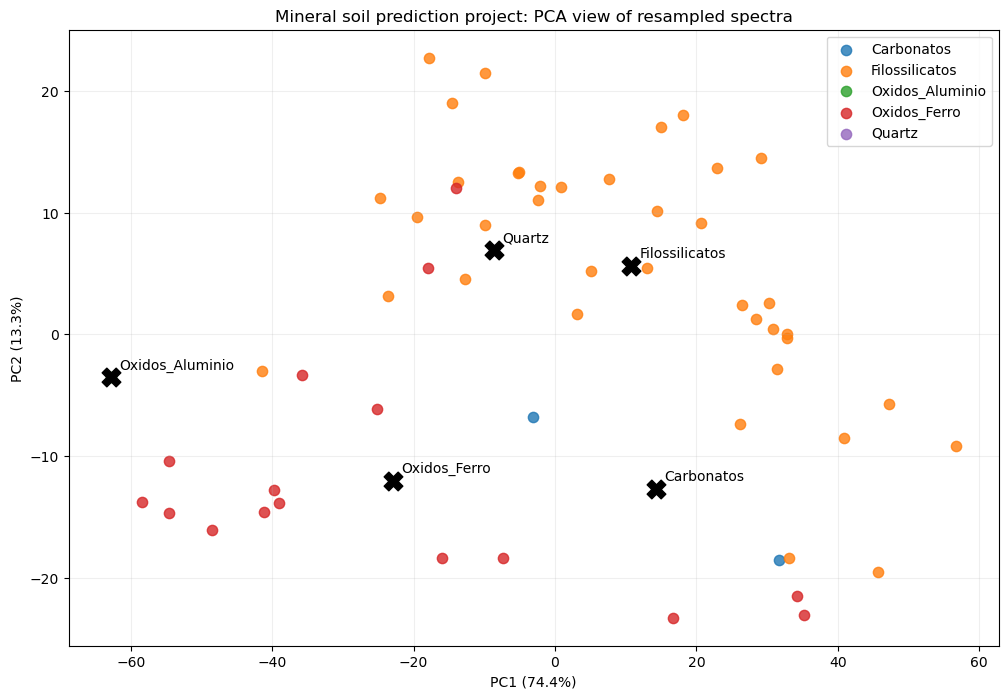


Top file-level predictions:
                                                                                                             file      true_label predicted_label  best_distance  margin_to_second  confidence
                   c:\Users\PC\Desktop\New data\quartzo-20260519T145447Z-3-001\quartzo\quartz_gds74.19086.asc.txt          Quartz          Quartz       0.000000         39.050869    1.000000
  c:\Users\PC\Desktop\New data\oxidos_aluminio-20260519T145744Z-3-001\oxidos_aluminio\gibbsite_hs423.8069.asc.txt Oxidos_Aluminio Oxidos_Aluminio       0.000001         41.853492    0.999999
    c:\Users\PC\Desktop\New data\filossilicatos-20260519T145957Z-3-001\filossilicatos\kaolinite_cm3.11802.asc.txt  Filossilicatos  Filossilicatos      10.385458         30.538059    0.087831
      c:\Users\PC\Desktop\New data\filossilicatos-20260519T145957Z-3-001\filossilicatos\illite_imt1.10996.asc.txt  Filossilicatos  Filossilicatos      10.704205         21.469780    0.085439
    c:\Users\PC\

In [24]:
# Mineral soil prediction project from the New data folder
from pathlib import Path
import json
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.interpolate import PchipInterpolator
from sklearn.decomposition import PCA
from sklearn.metrics import pairwise_distances
from sklearn.neighbors import NearestCentroid
from sklearn.preprocessing import StandardScaler

root = Path(r'c:\Users\PC\Desktop\New data')
project_dir = root / 'mineral_soil_prediction_project'
project_dir.mkdir(exist_ok=True)

# Mineral groups to use as labels for the project.
group_specs = {
    'Carbonatos': ['carbonatos'],
    'Filossilicatos': ['filossilicatos'],
    'Oxidos_Aluminio': ['oxidos_aluminio'],
    'Oxidos_Ferro': ['oxidos_ferro'],
    'Quartz': ['quartzo']
}

# Find all spectra for each group.
group_files = {}
for label, patterns in group_specs.items():
    files = []
    for pattern in patterns:
        for f in root.rglob('*'):
            if f.is_file() and f.suffix.lower() in ('.asc', '.txt') and pattern in str(f.parent).lower():
                files.append(f)
    files = sorted(set(files))
    if files:
        group_files[label] = files
        print(f'{label}: {len(files)} files')
    else:
        print(f'{label}: no files found')

if not group_files:
    raise FileNotFoundError('No mineral spectra were found under New data')

# Use the overlap common to all selected files so every spectrum lands on the same feature grid.
wl_mins = []
wl_maxs = []
loaded = {}
for label, files in group_files.items():
    for f in files:
        wl, refl, sd = load_usgs_spectrum(f)
        loaded[f] = (wl, refl, sd)
        wl_mins.append(wl.min())
        wl_maxs.append(wl.max())

wl_min = max(wl_mins)
wl_max = min(wl_maxs)
if wl_min >= wl_max:
    raise ValueError(f'No overlapping wavelength range across selected mineral files: {wl_min} >= {wl_max}')

wl_grid = np.linspace(wl_min, wl_max, 1200)
print(f'Common modeling grid: {wl_min:.4f} to {wl_max:.4f} microns with {wl_grid.size} points')

# Build feature matrix.
rows = []
for label, files in group_files.items():
    for f in files:
        wl, refl, _ = loaded[f]
        interp = PchipInterpolator(wl, refl, extrapolate=False)
        x = np.clip(np.nan_to_num(interp(wl_grid), nan=np.nan), 0.0, 1.0)
        rows.append({
            'file': str(f),
            'label': label,
            'features': x
        })

if not rows:
    raise ValueError('No feature rows could be created from the mineral spectra')

X = np.vstack([r['features'] for r in rows])
y = np.array([r['label'] for r in rows])
file_paths = np.array([r['file'] for r in rows])

# Model: standardize spectra, then classify with nearest centroid.
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
classifier = NearestCentroid()
classifier.fit(X_scaled, y)

# Training predictions and a simple confidence metric.
distances = pairwise_distances(X_scaled, classifier.centroids_)
pred_idx = distances.argmin(axis=1)
predicted = classifier.classes_[pred_idx]
sorted_distances = np.sort(distances, axis=1)
best_distance = sorted_distances[:, 0]
second_distance = sorted_distances[:, 1] if sorted_distances.shape[1] > 1 else sorted_distances[:, 0]
confidence = 1.0 / (1.0 + best_distance)
margin = second_distance - best_distance

pred_df = pd.DataFrame({
    'file': file_paths,
    'true_label': y,
    'predicted_label': predicted,
    'best_distance': best_distance,
    'margin_to_second': margin,
    'confidence': confidence
})

# Folder-mean predictions.
folder_rows = []
for label, files in group_files.items():
    vectors = []
    for f in files:
        wl, refl, _ = loaded[f]
        interp = PchipInterpolator(wl, refl, extrapolate=False)
        x = np.clip(np.nan_to_num(interp(wl_grid), nan=np.nan), 0.0, 1.0)
        vectors.append(x)
    mean_vec = np.nanmean(np.vstack(vectors), axis=0)
    mean_scaled = scaler.transform(mean_vec.reshape(1, -1))
    mean_distances = pairwise_distances(mean_scaled, classifier.centroids_).ravel()
    mean_pred = classifier.classes_[mean_distances.argmin()]
    folder_rows.append({
        'label': label,
        'predicted_label': mean_pred,
        'best_distance': float(mean_distances.min()),
        'confidence': float(1.0 / (1.0 + mean_distances.min())),
        'num_files': len(files)
    })

folder_df = pd.DataFrame(folder_rows)

# Save outputs.
pred_csv = project_dir / 'mineral_soil_file_predictions.csv'
folder_csv = project_dir / 'mineral_soil_folder_predictions.csv'
model_path = project_dir / 'mineral_soil_nearest_centroid.joblib'
meta_path = project_dir / 'mineral_soil_prediction_metadata.json'

pred_df.to_csv(pred_csv, index=False)
folder_df.to_csv(folder_csv, index=False)
joblib.dump({'scaler': scaler, 'classifier': classifier, 'wavelength_grid': wl_grid}, model_path)
meta = {
    'wavelength_min_um': float(wl_min),
    'wavelength_max_um': float(wl_max),
    'grid_points': int(wl_grid.size),
    'groups': list(group_files.keys()),
    'files_per_group': {k: len(v) for k, v in group_files.items()},
}
meta_path.write_text(json.dumps(meta, indent=2), encoding='utf-8')

print('Saved file predictions to:', pred_csv)
print('Saved folder predictions to:', folder_csv)
print('Saved model to:', model_path)

# Report accuracy on the training set as a baseline only.
training_accuracy = float((pred_df['true_label'] == pred_df['predicted_label']).mean())
print(f'Training-set nearest-centroid accuracy: {training_accuracy:.3f}')
print('Folder predictions:')
print(folder_df.to_string(index=False))

# Visualize class means and the first two PCA components.
class_means = []
class_labels = []
for label in classifier.classes_:
    class_means.append(X_scaled[y == label].mean(axis=0))
    class_labels.append(label)
class_means = np.vstack(class_means)

pca = PCA(n_components=2, random_state=0)
X_pca = pca.fit_transform(X_scaled)
centroid_pca = pca.transform(classifier.centroids_)
mean_pca = pca.transform(class_means)

fig, ax = plt.subplots(figsize=(12, 8))
colors = plt.cm.tab10.colors
for idx, label in enumerate(classifier.classes_):
    mask = y == label
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1], s=55, alpha=0.8, color=colors[idx % len(colors)], label=label)
    ax.scatter(centroid_pca[idx, 0], centroid_pca[idx, 1], s=180, marker='X', color='black')
    ax.annotate(label, (centroid_pca[idx, 0], centroid_pca[idx, 1]), xytext=(6, 6), textcoords='offset points')
ax.set_title('Mineral soil prediction project: PCA view of resampled spectra')
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})')
ax.grid(alpha=0.2)
ax.legend(loc='best')
plt.show()

# Show the strongest predicted labels for each file.
print('\nTop file-level predictions:')
print(pred_df.sort_values(['confidence', 'margin_to_second'], ascending=False).head(12).to_string(index=False))


C:\Users\PC\AppData\Local\Temp\ipykernel_14896\3593134478.py:49: RuntimeWarning: Mean of empty slice
  observed = np.nanmean(np.vstack(obs_stack), axis=0)



Filossilicatos:
  Prominent bands detected: 3
  band near 1.4100 microns, reflectance 0.4924
  band near 2.2060 microns, reflectance 0.4321
  band near 1.9100 microns, reflectance 0.5441

Oxidos_Aluminio:
  Prominent bands detected: 2
  band near 1.5210 microns, reflectance 0.1443
  band near 2.2660 microns, reflectance 0.0526

Oxidos_Ferro:
  Prominent bands detected: 4
  band near 1.5980 microns, reflectance 0.2157
  band near 1.4180 microns, reflectance 0.3162
  band near 1.4510 microns, reflectance 0.2937
  band near 1.5150 microns, reflectance 0.2221

Carbonatos:
  Prominent bands detected: 1
  band near 2.3250 microns, reflectance 0.4881

Quartz:
  No prominent absorption bands detected with the current threshold.


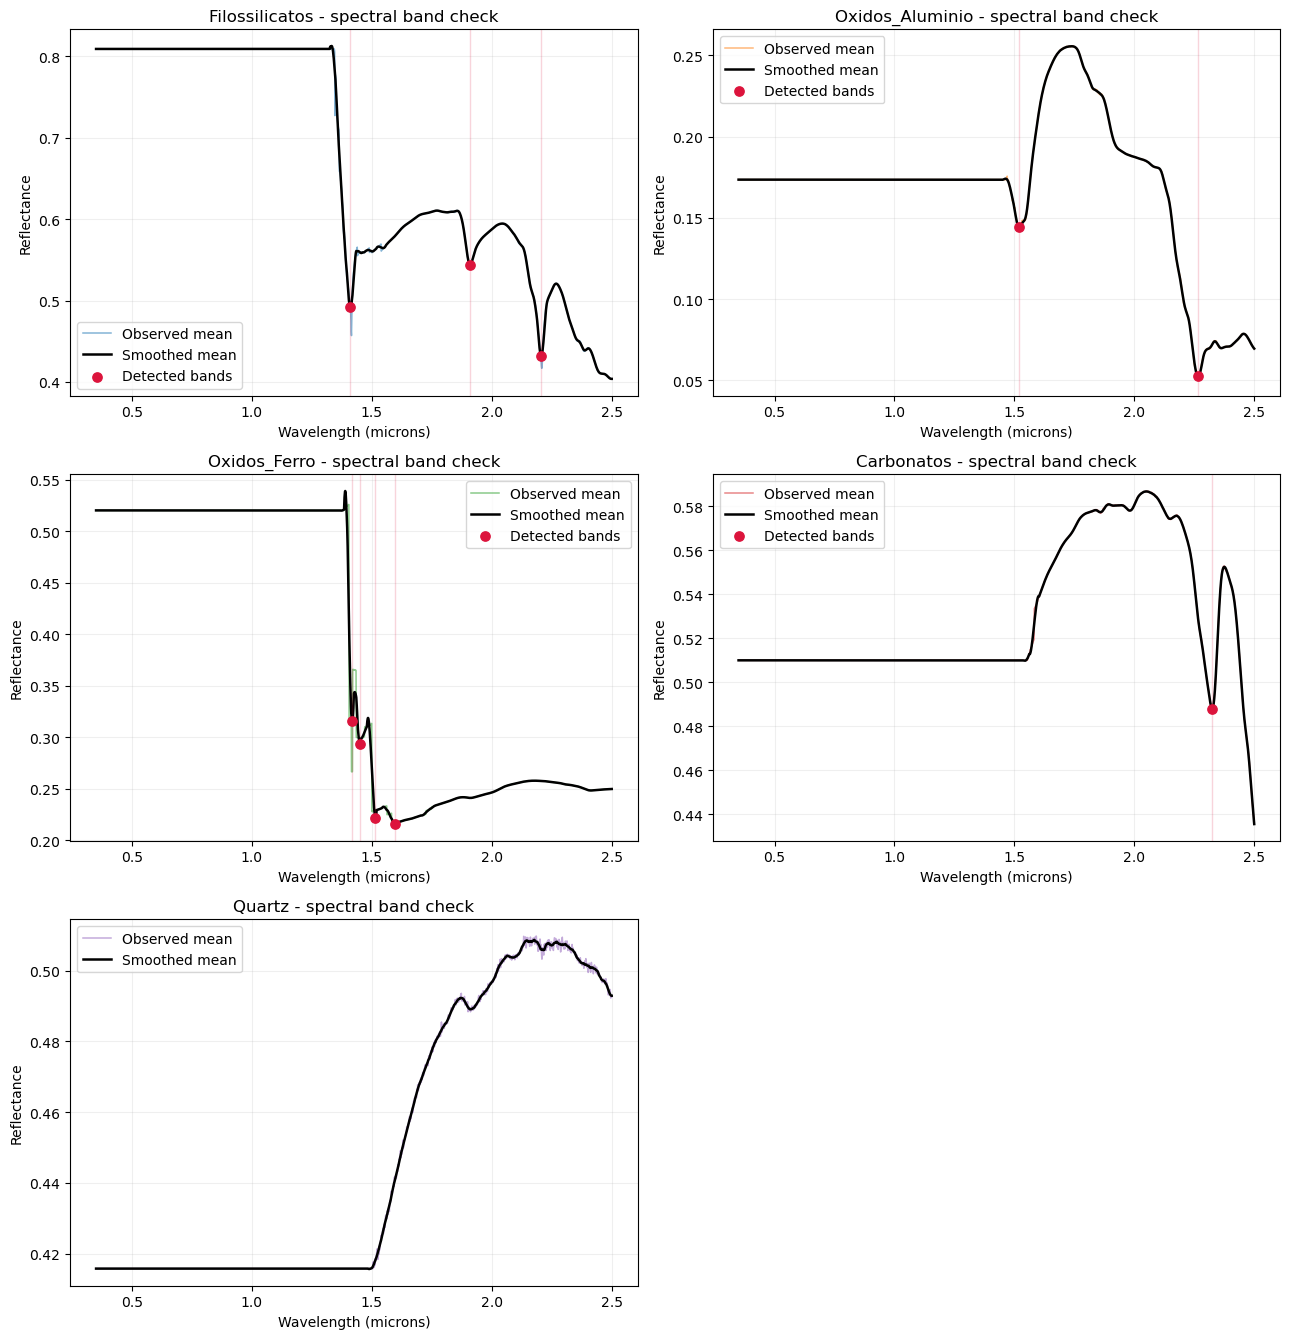


Summary:
  Filossilicatos: bands exist? yes (detected 3 candidate bands)
  Oxidos_Aluminio: bands exist? yes (detected 2 candidate bands)
  Oxidos_Ferro: bands exist? yes (detected 4 candidate bands)
  Carbonatos: bands exist? yes (detected 1 candidate bands)
  Quartz: bands exist? no (detected 0 candidate bands)


In [26]:
# Check whether diagnostic spectral bands exist in the mineral groups
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks, savgol_filter

root = Path(r'c:\Users\PC\Desktop\New data')
out_root = root / 'resampled_outputs_all_data'

# Work from folder-level observed means when available; otherwise fall back to file-level CSV aggregation.
mineral_folders = {
    'Filossilicatos': 'filossilicatos',
    'Oxidos_Aluminio': 'oxidos_aluminio',
    'Oxidos_Ferro': 'oxidos_ferro',
    'Carbonatos': 'carbonatos',
    'Quartz': 'quartzo'
}

band_results = {}

def load_mean_curve(folder_name: str):
    obs_file = out_root / f'{folder_name}_observed_mean.csv'
    beh_file = out_root / f'{folder_name}_behaviour_mean.csv'
    wl = None
    observed = None
    behaviour = None

    if obs_file.exists():
        data = np.loadtxt(obs_file, delimiter=',', skiprows=1)
        wl = data[:, 0]
        observed = data[:, 1]
    if beh_file.exists():
        data = np.loadtxt(beh_file, delimiter=',', skiprows=1)
        wl = data[:, 0]
        behaviour = data[:, 1]

    if observed is None:
        files = [p for p in out_root.rglob('*.csv') if folder_name in p.parts and 'behaviour' not in p.name.lower()]
        obs_stack = []
        for p in files:
            try:
                d = np.loadtxt(p, delimiter=',', skiprows=1)
                if wl is None:
                    wl = d[:, 0]
                obs_stack.append(d[:, 1])
            except Exception:
                continue
        if obs_stack:
            observed = np.nanmean(np.vstack(obs_stack), axis=0)

    return wl, observed, behaviour

for label, folder in mineral_folders.items():
    wl, observed, behaviour = load_mean_curve(folder)
    if wl is None or observed is None:
        print(f'{label}: no mean curve available')
        continue

    observed = np.asarray(observed, dtype=float)
    finite = np.isfinite(observed)
    if finite.sum() < 7:
        print(f'{label}: not enough finite points to detect bands')
        continue

    # Fill NaNs by interpolation before smoothing.
    observed_filled = observed.copy()
    if not finite.all():
        observed_filled[~finite] = np.interp(wl[~finite], wl[finite], observed[finite])

    # Smooth before band finding; use a small odd window if the curve is long enough.
    window = min(41, len(observed_filled) - (1 - len(observed_filled) % 2))
    if window < 7 or window <= 3:
        smooth = observed_filled
    else:
        if window % 2 == 0:
            window -= 1
        try:
            smooth = savgol_filter(observed_filled, window_length=window, polyorder=3, mode='interp')
        except Exception:
            smooth = observed_filled

    # Absorption bands appear as local minima in reflectance.
    inverted = -smooth
    peaks, props = find_peaks(inverted, prominence=0.01, distance=max(10, len(wl) // 100))
    band_centers = wl[peaks]
    band_depths = smooth[peaks]

    # Save only the strongest few bands.
    order = np.argsort(props['prominences'])[::-1] if len(peaks) else []
    top_idx = order[:5] if len(peaks) else []
    top_centers = band_centers[top_idx] if len(peaks) else np.array([])
    top_depths = band_depths[top_idx] if len(peaks) else np.array([])

    band_results[label] = {
        'wl': wl,
        'observed': observed_filled,
        'smooth': smooth,
        'peaks': peaks,
        'top_centers': top_centers,
        'top_depths': top_depths,
        'n_bands': int(len(peaks)),
    }

    print(f'\n{label}:')
    if len(top_centers) == 0:
        print('  No prominent absorption bands detected with the current threshold.')
    else:
        print(f'  Prominent bands detected: {len(peaks)}')
        for c, d in zip(top_centers, top_depths):
            print(f'  band near {c:.4f} microns, reflectance {d:.4f}')

# Plot each mineral group and mark detected bands.
if band_results:
    n = len(band_results)
    cols = 2
    rows = (n + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(13, 4.5 * rows), squeeze=False)
    colors = plt.cm.tab10.colors

    for idx, (label, data) in enumerate(band_results.items()):
        r = idx // cols
        c = idx % cols
        ax = axes[r][c]
        wl = data['wl']
        observed = data['observed']
        smooth = data['smooth']
        ax.plot(wl, observed, color=colors[idx % len(colors)], lw=1.1, alpha=0.55, label='Observed mean')
        ax.plot(wl, smooth, color='black', lw=1.8, label='Smoothed mean')
        if len(data['peaks']) > 0:
            ax.scatter(wl[data['peaks']], smooth[data['peaks']], color='crimson', s=45, zorder=3, label='Detected bands')
            for x in data['top_centers']:
                ax.axvline(x, color='crimson', alpha=0.18, lw=1)
        ax.set_title(f'{label} - spectral band check')
        ax.set_xlabel('Wavelength (microns)')
        ax.set_ylabel('Reflectance')
        ax.grid(alpha=0.2)
        ax.legend()

    total = rows * cols
    for idx in range(n, total):
        r = idx // cols
        c = idx % cols
        fig.delaxes(axes[r][c])

    plt.tight_layout()
    plt.show()

# Short yes/no summary based on band detection counts.
print('\nSummary:')
for label, data in band_results.items():
    exists = 'yes' if data['n_bands'] > 0 else 'no'
    print(f'  {label}: bands exist? {exists} (detected {data["n_bands"]} candidate bands)')


In [ ]:
from pathlib import Path
from datetime import datetime, timedelta

import importlib
import subprocess
import sys

required_packages = [
    'geopandas',
    'geobr',
    'rasterio',
    'pystac-client',
    'planetary-computer',
    'stackstac',
    'folium',
    'pyproj',
    'shapely',
    'xarray',
    'rioxarray',
]

missing_packages = []
for package_name in required_packages:
    module_name = package_name.replace('-', '_')
    try:
        importlib.import_module(module_name)
    except ImportError:
        missing_packages.append(package_name)

if missing_packages:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *missing_packages])

if importlib.util.find_spec('xarray.namedarray') is None:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', '--upgrade', 'xarray'])

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import xarray as xr
from pystac_client import Client
from planetary_computer import sign
import stackstac
import geobr

# Optional but useful for raster exports.
import rioxarray  # noqa: F401

output_dir = Path('piracicaba_geospatial_exports')
output_dir.mkdir(parents=True, exist_ok=True)


def read_geobr_layer(loader_name, attempts):
    loader = getattr(geobr, loader_name)
    last_error = None
    for kwargs in attempts:
        try:
            return loader(**kwargs)
        except Exception as exc:
            last_error = exc
    raise RuntimeError(f'Could not load {loader_name}: {last_error}')


brazil = read_geobr_layer(
    'read_country',
    [
        {'year': 2020},
        {'year': 2010},
        {},
    ],
)
state_sp = read_geobr_layer(
    'read_state',
    [
        {'code_state': 'SP', 'year': 2020},
        {'code_state': 35, 'year': 2020},
        {'code_state': 'SP'},
        {'code_state': 35},
    ],
)
piracicaba = read_geobr_layer(
    'read_municipality',
    [
        {'code_muni': 3538709, 'year': 2020},
        {'code_muni': 3538709},
        {'code_mun': 3538709, 'year': 2020},
        {'code_mun': 3538709},
    ],
)

# Standardize CRS for the boundary maps.
brazil_wgs84 = brazil.to_crs(4326)
state_sp_wgs84 = state_sp.to_crs(4326)
piracicaba_wgs84 = piracicaba.to_crs(4326)
piracicaba_utm = piracicaba_wgs84.to_crs(32723)

# Context map: Brazil -> São Paulo -> Piracicaba.
fig, ax = plt.subplots(figsize=(10, 10))
brazil_wgs84.plot(ax=ax, color='#d9d9d9', edgecolor='#9e9e9e', linewidth=0.6)
state_sp_wgs84.plot(ax=ax, color='#4db6ac', edgecolor='#00695c', linewidth=0.8)
piracicaba_wgs84.plot(ax=ax, color='#ef5350', edgecolor='#7f0000', linewidth=1.3)
ax.set_title('Brazil, São Paulo and Piracicaba boundaries', fontsize=14, fontweight='bold')
ax.set_axis_off()
context_map_path = output_dir / 'piracicaba_context_map.png'
fig.savefig(context_map_path, dpi=220, bbox_inches='tight')
plt.show()

# Satellite search over Piracicaba using Sentinel-2 L2A.
geometry = piracicaba_wgs84.geometry.iloc[0]
end_date = pd.Timestamp.utcnow().normalize().date()
start_date = (pd.Timestamp.utcnow().normalize() - pd.Timedelta(days=365)).date()
date_range = f'{start_date}/{end_date}'

satellite_ok = False
satellite_error = None
items = []
mosaic = None
ndvi = None
ndre = None
yield_proxy = None
nutrition_proxy = None

try:
    catalog = Client.open('https://planetarycomputer.microsoft.com/api/stac/v1')
    search = catalog.search(
        collections=['sentinel-2-l2a'],
        intersects=geometry.__geo_interface__,
        datetime=date_range,
        query={'eo:cloud_cover': {'lt': 35}},
        max_items=10,
    )
    items = list(search.items())
    items = sorted(items, key=lambda item: item.properties.get('eo:cloud_cover', 100.0))[:8]

    if not items:
        raise RuntimeError(f'No Sentinel-2 items found for {date_range}')

    items = [sign(item) for item in items]

    import rasterio
    from rasterio.mask import mask
    from rasterio.transform import array_bounds

    signed_item = items[0]

    def read_band(asset_key):
        asset_href = signed_item.assets[asset_key].href
        with rasterio.open(asset_href) as src:
            geom_src = piracicaba_wgs84.to_crs(src.crs).geometry.iloc[0]
            band_data, band_transform = mask(src, [geom_src.__geo_interface__], crop=True, filled=True, nodata=src.nodata)
            band_array = band_data[0].astype('float32')
            if src.nodata is not None:
                band_array = np.where(band_array == src.nodata, np.nan, band_array)
            if np.nanmax(np.abs(band_array)) > 1.5:
                band_array = band_array / 10000.0
            return band_array, band_transform, src.crs

    red, transform, source_crs = read_band('B04')
    green, _, _ = read_band('B03')
    blue, _, _ = read_band('B02')
    nir, _, _ = read_band('B08')

    if np.isnan(red).all() or np.isnan(nir).all():
        raise RuntimeError('Sentinel-2 bands were empty after clipping to Piracicaba.')

    ndvi = np.where((nir + red) != 0, (nir - red) / (nir + red), np.nan)
    green_index = np.where((nir + green) != 0, (nir - green) / (nir + green), np.nan)
    yield_proxy = np.clip(ndvi, 0, 1) * 100.0
    nutrition_proxy = (np.clip(ndvi, 0, 1) + np.clip(green_index, 0, 1)) / 2.0 * 100.0
    satellite_ok = True
except Exception as exc:
    satellite_error = exc
    print(f'Satellite composite unavailable: {exc}')

if satellite_ok:
    # Export rasters for downstream use.
    for layer_name, layer_data in [
        ('ndvi', ndvi),
        ('yield_proxy', yield_proxy),
        ('nutrition_proxy', nutrition_proxy),
    ]:
        export_path = output_dir / f'piracicaba_{layer_name}.tif'
        export_array = np.where(np.isnan(layer_data), -9999.0, layer_data).astype('float32')
        with rasterio.open(
            export_path,
            'w',
            driver='GTiff',
            height=export_array.shape[0],
            width=export_array.shape[1],
            count=1,
            dtype='float32',
            crs=source_crs,
            transform=transform,
            nodata=-9999.0,
            compress='deflate',
        ) as dst:
            dst.write(export_array, 1)

    summary = pd.DataFrame(
        {
            'layer': ['ndvi', 'yield_proxy', 'nutrition_proxy'],
            'mean': [float(np.nanmean(ndvi)), float(np.nanmean(yield_proxy)), float(np.nanmean(nutrition_proxy))],
            'min': [float(np.nanmin(ndvi)), float(np.nanmin(yield_proxy)), float(np.nanmin(nutrition_proxy))],
            'max': [float(np.nanmax(ndvi)), float(np.nanmax(yield_proxy)), float(np.nanmax(nutrition_proxy))],
        }
    )
    summary_path = output_dir / 'piracicaba_satellite_summary.csv'
    summary.to_csv(summary_path, index=False)

    # Compose the final multi-panel visual.
    fig, axes = plt.subplots(2, 2, figsize=(16, 14))
    west, south, east, north = array_bounds(red.shape[0], red.shape[1], transform)
    extent = [west, east, south, north]

    rgb_stack = np.dstack([
        np.nan_to_num(red, nan=np.nanpercentile(red, 2)),
        np.nan_to_num(green, nan=np.nanpercentile(green, 2)),
        np.nan_to_num(blue, nan=np.nanpercentile(blue, 2)),
    ])
    rgb_min = np.nanpercentile(rgb_stack, 2)
    rgb_max = np.nanpercentile(rgb_stack, 98)
    rgb_display = np.clip((rgb_stack - rgb_min) / (rgb_max - rgb_min + 1e-6), 0, 1)

    panels = [
        (
            'RGB composite',
            None,
            None,
            None,
        ),
        (
            ndvi,
            'NDVI map',
            {'cmap': 'YlGn', 'vmin': -0.2, 'vmax': 0.9},
            '#1b5e20',
        ),
        (
            yield_proxy,
            'Sugarcane production proxy',
            {'cmap': 'viridis', 'vmin': 0, 'vmax': 100},
            '#4a148c',
        ),
        (
            nutrition_proxy,
            'Vegetation nutrition proxy',
            {'cmap': 'plasma', 'vmin': 0, 'vmax': 100},
            '#bf360c',
        ),
    ]

    for idx, (ax, (data, title, plot_kwargs, edge_color)) in enumerate(zip(axes.ravel(), panels)):
        if idx == 0:
            ax.imshow(rgb_display, extent=extent, origin='upper')
        else:
            ax.imshow(data, extent=extent, origin='upper', **plot_kwargs)
        piracicaba_utm.plot(ax=ax, facecolor='none', edgecolor=edge_color or '#ffffff', linewidth=1.4)
        ax.set_title(title, fontsize=13, fontweight='bold')
        ax.set_axis_off()

    plt.suptitle('Piracicaba-SP satellite mapping for sugarcane behavior', fontsize=16, fontweight='bold')
    plt.tight_layout()
    map_panel_path = output_dir / 'piracicaba_satellite_maps.png'
    fig.savefig(map_panel_path, dpi=220, bbox_inches='tight')
    plt.show()

    # A simple threshold delineation of the strongest vegetative areas.
    high_production = yield_proxy >= float(np.nanquantile(yield_proxy, 0.75))
    fig, ax = plt.subplots(figsize=(10, 10))
    ax.imshow(yield_proxy, extent=extent, origin='upper', cmap='YlGn', vmin=0, vmax=100)
    piracicaba_utm.plot(ax=ax, facecolor='none', edgecolor='black', linewidth=1.3)
    ax.imshow(np.where(high_production, 1.0, np.nan), extent=extent, origin='upper', cmap='Reds', alpha=0.28, vmin=0, vmax=1)
    ax.set_title('High-production zone delineation inside Piracicaba', fontsize=13, fontweight='bold')
    ax.set_axis_off()
    delineation_path = output_dir / 'piracicaba_high_production_zone.png'
    fig.savefig(delineation_path, dpi=220, bbox_inches='tight')
    plt.show()

    print('Saved files:')
    print(f'  {context_map_path}')
    print(f'  {map_panel_path}')
    print(f'  {delineation_path}')
    print(f'  {summary_path}')
    print(f'  {output_dir / "piracicaba_ndvi.tif"}')
    print(f'  {output_dir / "piracicaba_yield_proxy.tif"}')
    print(f'  {output_dir / "piracicaba_nutrition_proxy.tif"}')
else:
    print('Boundary map was created, but the satellite composite could not be generated.')
    print(f'  Reason: {satellite_error}')
